<a href="https://colab.research.google.com/github/Bhuvneshwari19/flipkart-product-clustering/blob/main/flipkart_products.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -** Bhuvneshwari


# **Project Summary -**

This project focused on clustering products from the Flipkart product dataset using unsupervised machine learning techniques. Since the dataset did not contain predefined target labels, clustering was chosen to discover hidden patterns and group similar products automatically. The dataset contained product information such as product name, prices, discounts, ratings, brand, category, descriptions, and product specifications, making it suitable for segmentation analysis.

The project began with data understanding and exploratory data analysis (EDA). Various visualizations were created to analyze the distribution of prices, discounts, ratings, brands, categories, and relationships between important variables. These visualizations provided valuable insights into the overall structure of the dataset and highlighted the need for data cleaning and preprocessing before model building.

The data preprocessing stage involved removing irrelevant columns, handling missing values, eliminating duplicate records, parsing category information, calculating discount percentage, and treating outliers using the IQR method. Categorical variables such as brand and product category were encoded using Label Encoding. Since the dataset also contained textual information, several NLP preprocessing techniques were applied, including contraction expansion, lowercasing, punctuation removal, URL removal, stopword removal, whitespace removal, tokenization, lemmatization, part-of-speech tagging, and TF-IDF vectorization. These steps transformed the text into meaningful numerical representations suitable for clustering.

Feature engineering was performed to create useful variables such as discount percentage, while correlation analysis was used to minimize redundant information by removing highly correlated features. Numerical, categorical, and TF-IDF features were then combined into a single feature matrix. Since the TF-IDF representation generated a high-dimensional feature space, Truncated Singular Value Decomposition (TruncatedSVD) was applied to reduce the dimensionality to 100 components while preserving approximately 94.31% of the original information. This improved computational efficiency without significant information loss.

Three clustering algorithms were implemented and compared: K-Means Clustering, Agglomerative Hierarchical Clustering, and DBSCAN. For K-Means, the Elbow Method was used to determine the optimal number of clusters, resulting in K = 6. The model achieved a Silhouette Score of 0.2898 and produced six meaningful product clusters. Hierarchical Clustering was implemented using Ward linkage with six clusters and achieved a Silhouette Score of 0.2160. DBSCAN was also evaluated using different combinations of eps and min_samples, successfully identifying dense product groups and noise points.

Hyperparameter tuning was performed for all three models using the Silhouette Score. Although some tuned configurations produced higher Silhouette Scores (approximately 0.55), they generated only two broad and highly imbalanced clusters. These clusters were less useful for business applications because they failed to provide meaningful product segmentation. Therefore, cluster interpretability and business usefulness were considered alongside evaluation metrics when selecting the final model.

Based on both quantitative evaluation and qualitative analysis, K-Means Clustering (K = 6) was selected as the final model. It provided the best balance between cluster quality, interpretability, and practical business value. The resulting clusters can support product recommendation systems, customer segmentation, pricing optimization, inventory planning, and targeted marketing campaigns. Overall, this project demonstrates how clustering techniques can effectively organize large product datasets and generate actionable business insights without requiring labeled data.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


With thousands of products available on e-commerce platforms like Flipkart, it becomes challenging to organize products effectively, provide personalized recommendations, and understand product similarities. Products differ in terms of price, discounts, ratings, brand, category, and textual descriptions, making manual segmentation impractical. The objective of this project is to apply unsupervised machine learning (clustering) techniques to group similar Flipkart products into meaningful clusters based on their numerical, categorical, and textual features. These clusters can help improve recommendation systems, inventory management, targeted marketing, and pricing strategies by identifying products with similar characteristics.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [ ]:
# Load Dataset
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("PromptCloudHQ/flipkart-products")
print("Path to dataset files:", path)
print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "flipkart_com-ecommerce_sample.csv"))

100%|██████████| 5.50M/5.50M [00:00<00:00, 62.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/PromptCloudHQ/flipkart-products/versions/1
['flipkart_com-ecommerce_sample.csv']


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",..."


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(20000, 15)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  20000 non-null  object 
 1   crawl_timestamp          20000 non-null  object 
 2   product_url              20000 non-null  object 
 3   product_name             20000 non-null  object 
 4   product_category_tree    20000 non-null  object 
 5   pid                      20000 non-null  object 
 6   retail_price             19922 non-null  float64
 7   discounted_price         19922 non-null  float64
 8   image                    19997 non-null  object 
 9   is_FK_Advantage_product  20000 non-null  bool   
 10  description              19998 non-null  object 
 11  product_rating           20000 non-null  object 
 12  overall_rating           20000 non-null  object 
 13  brand                    14136 non-null  object 
 14  product_specifications

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
uniq_id,0
crawl_timestamp,0
product_url,0
product_name,0
product_category_tree,0
pid,0
retail_price,78
discounted_price,78
image,3
is_FK_Advantage_product,0


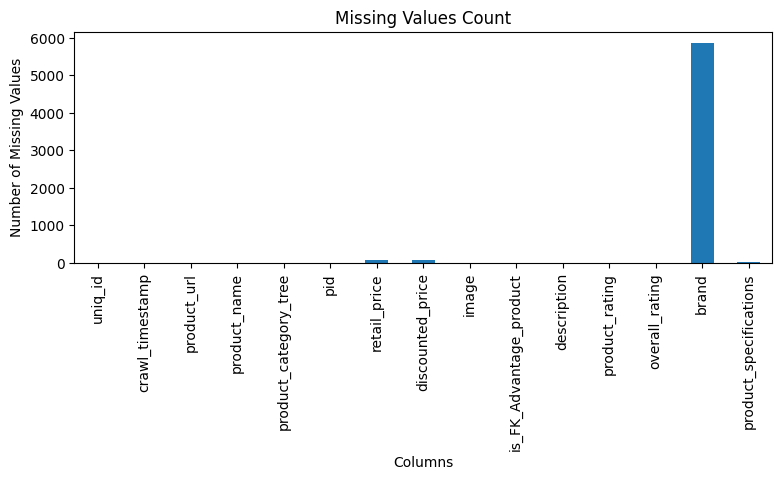

In [ ]:
# Visualizing the missing values
missing_values=df.isnull().sum()
plt.figure(figsize=(9,3))
missing_values.plot(kind='bar')

plt.title("Missing Values Count")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)
plt.show()

### What did you know about your dataset?

* Number of rows: 20000

* Number of columns: 15

* Duplicate rows: 0

* Categorical features: (12) [uniq_id, crawl_timestamp, product_url, product_name, product_category_tree, pid, image, description, product_rating, overall_rating, brand, product_specifications]

* Numerical features: (2) [retail_price, discounted_price]

* Boolean feature: (1) [is_FK_Advantage_product]

* Missing values: [brand: 5864, retail_price: 78, discounted_price: 78, product_specifications: 14, image: 3, description: 2]



## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['uniq_id', 'crawl_timestamp', 'product_url', 'product_name',
       'product_category_tree', 'pid', 'retail_price', 'discounted_price',
       'image', 'is_FK_Advantage_product', 'description', 'product_rating',
       'overall_rating', 'brand', 'product_specifications'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,retail_price,discounted_price
count,19922.000000,19922.000000
mean,2979.206104,1973.401767
std,9009.639341,7333.586040
min,35.000000,35.000000
25%,666.000000,350.000000
50%,1040.000000,550.000000
75%,1999.000000,999.000000
max,571230.000000,571230.000000


### Variables Description

* uniq_id: The unique tracking ID generated for each specific product entry in the database.
* crawl_timestamp: The exact date, time, and timezone when this specific product information was fetched/scraped from the live website.
* product_url: The webpage link leading directly to the product listing on the e-commerce website.
* product_name: The title or name of the product as displayed to customers.
* product_category_tree: A string showing the hierarchy of categories the product belongs to, from broad to narrow (e.g., ["Clothing >> Women's Clothing >> Shorts"]).  
* pid: The alphanumeric unique Product ID used by the platform to manage stock and inventory.
* retail_price: The original price tag or Maximum Retail Price (MRP) before discounts.  
* discounted_price: The actual final selling price of the product after any sales or promotions are applied.  
* image: An array of links pointing to the hosted image files for the product.
* is_FK_Advantage_product: A true/false flag indicating whether the product is handled by the platform's premium fulfillment service (faster delivery, checked sellers).
* description: A detailed paragraph outlining the features, highlights, and specifications of the item.
* product_rating: The star rating (typically on a scale of 1 to 5) given by buyers specifically for this product item. (Note: In this dataset, this often contains the text "No rating available" if no one has reviewed it yet).

* overall_rating: The overall summary rating of the seller or the brand across the entire platform, rather than just this single product.

* brand: The manufacturer, company, or brand name under which the product is being sold (e.g., Alisha, FabHomeDecor).

* product_specifications: A structured text block (stored like a Python dictionary) containing technical metadata about the product's specific attributes, such as material, size, color, weight, and key features.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for i in df.columns:
    print(f"{i}:  {[df[i].nunique()]} unique values")

uniq_id:  [20000] unique values
crawl_timestamp:  [371] unique values
product_url:  [20000] unique values
product_name:  [12676] unique values
product_category_tree:  [6466] unique values
pid:  [19998] unique values
retail_price:  [2247] unique values
discounted_price:  [2448] unique values
image:  [18589] unique values
is_FK_Advantage_product:  [2] unique values
description:  [17539] unique values
product_rating:  [36] unique values
overall_rating:  [36] unique values
brand:  [3499] unique values
product_specifications:  [18825] unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:

# 1. DROP IRRELEVANT COLUMNS

# These columns have unique values per row and offer no value to clustering
columns_to_drop = ['uniq_id', 'pid', 'product_url', 'image', 'crawl_timestamp']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
print(f"Shape after dropping noise columns: {df.shape}")


# 2. HANDLE MISSING VALUES

# Drop rows where price data is completely missing
df.dropna(subset=['retail_price', 'discounted_price'], inplace=True)

# Fill missing brand names with a generic placeholder string
df['brand'].fillna('Unknown Brand', inplace=True)

df['product_specifications'] = df['product_specifications'].fillna('No specifications available')

# do the same for description
df['description'] = df['description'].fillna('No description available')

# Calculate the discount percentage as a new continuous numeric feature
df['discount_percentage'] = np.where(df['retail_price'] > 0,((df['retail_price'] - df['discounted_price']) / df['retail_price']) * 100,0.0)

# Round it up to two decimal places for neatness
df['discount_percentage'] = df['discount_percentage'].round(2)


# 4. PARSE CATEGORY STRINGS
def extract_primary_category(category_string):
    """
    Cleans string formatting like ["Clothing >> Women's Clothing"]
    and returns just the top-level parent category ('Clothing').
    """
    try:
        if isinstance(category_string, str):
            clean_str = category_string.strip("[]'\"")
            categories = [c.strip() for c in clean_str.split('>>')]
            if categories and categories[0] != '':
                return categories[0]
        return 'Unknown Category'
    except Exception:
        return 'Unknown Category'

# Apply the parsing function to create a clean text feature
df['primary_category'] = df['product_category_tree'].apply(extract_primary_category)

# Now we can safely drop the raw, messy tree column
df.drop(columns=['product_category_tree'], inplace=True)

# 5. VERIFY WRANGLED DATA PIPELINE

print("\n--- Wrangling Complete! ---")
print(f"Final shape for modeling pre-processing: {df.shape}")
print("\nMissing values remaining per column:")
print(df.isnull().sum())

Shape after dropping noise columns: (20000, 10)

--- Wrangling Complete! ---
Final shape for modeling pre-processing: (19922, 11)

Missing values remaining per column:
product_name               0
retail_price               0
discounted_price           0
is_FK_Advantage_product    0
description                0
product_rating             0
overall_rating             0
brand                      0
product_specifications     0
discount_percentage        0
primary_category           0
dtype: int64


/tmp/ipykernel_968/3719779184.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['brand'].fillna('Unknown Brand', inplace=True)


### What all manipulations have you done and insights you found?

* Deleted columns like uniq_id, product_url, and image. These are just tracking links and codes that confuse machine learning models.

* Deleted 78 products that had no price information at all, since you can't run calculations without numbers.

* Found thousands of products missing a brand name. Instead of leaving them broken, we labeled them as "Unknown Brand". We did the same for a few missing descriptions.

* Took messy strings like ["Clothing >> Women's Clothing >> Shorts"] and chopped them down to just the main category: Clothing.

* Calculated the exact discount_percentage for every single item so the model can easily see how big the price drop is.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

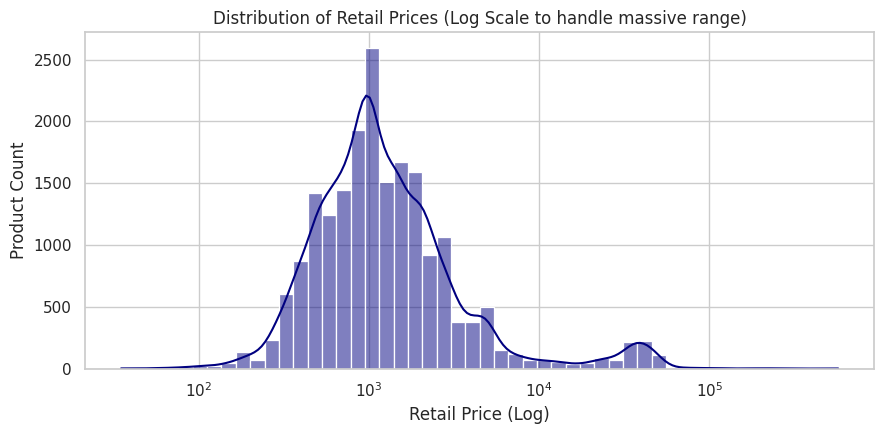

In [ ]:
# Chart - 1 visualization code
from wordcloud import WordCloud

# Set a clean, universal look
sns.set_theme(style="whitegrid")
# Filter outliers above 5000 just for clean visualization scaling where needed
df_filtered = df[df['retail_price'] <= 5000]

plt.figure(figsize=(9, 4.5))
sns.histplot(df['retail_price'], bins=50, kde=True, color='navy', log_scale=True)
plt.title('Distribution of Retail Prices (Log Scale to handle massive range)')
plt.xlabel('Retail Price (Log)')
plt.ylabel('Product Count')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

E-commerce items range from very cheap accessories to luxury products costing tens of thousands. A regular chart would squash all the cheap items into one giant unreadable wall.By using a logarithmic scale ($10^2, 10^3, 10^4$),we can see the true spread of both low-end and high-end prices simultaneously. The bars and smooth line instantly reveal where the bulk of the platform's inventory actually sits.

##### 2. What is/are the insight(s) found from the chart?

* The highest peak is right at the 1,000 mark. This tells us the platform's absolute bread-and-butter inventory consists of mid-tier items priced between 500 and 2,000 units.
* There is a small, separate bump further down the line near 30,000 to 50,000 units. This shows a distinct, smaller segment of premium luxury goods.
* The wide spread visually proves that a raw mathematical model will struggle without normalization. A 10% change on a luxury item is larger than the total price of a budget item, meaning data scaling is mandatory before clustering.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Since the massive peak sits around 1,000, marketing teams can focus bulk promotions on this high-volume mid-tier zone to maximize quick conversions.

negative growth :
high inventory risk in the secondary luxury bracket ($>30,000$ units). Pushing capital or warehouse space into this low-density tier will freeze cash flow due to significantly slower turnover rates compared to the core mid-tier market.

#### Chart - 2

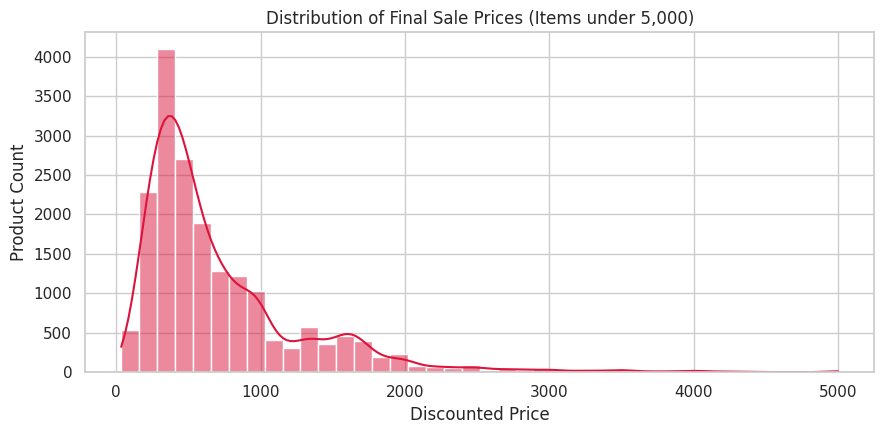

In [ ]:
# Chart - 2 visualization code

# Discounted Price Distribution (Zoomed Spread)

plt.figure(figsize=(9, 4.5))
sns.histplot(df_filtered['discounted_price'], bins=40, kde=True, color='crimson')
plt.title('Distribution of Final Sale Prices (Items under 5,000)')
plt.xlabel('Discounted Price')
plt.ylabel('Product Count')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

Filters out extreme luxury outliers to focus purely on high-volume items under 5,000 units.

 Uses a standard linear scale to reveal exact pricing cutoffs where most customer transactions occur.

##### 2. What is/are the insight(s) found from the chart?

* The 300–500 Sweet Spot: The massive spike means this platform is structurally built on low-cost items. The vast majority of stock consists of cheap, fast-moving products rather than mid-to-high tier goods.

* The Sharp Drop-off: Once an item crosses the 1,000 unit price point, inventory availability crashes instantly. It reveals a hard operational boundary where the platform transitions away from everyday consumer items.

* The Long Tail: The thin stretch out to 5,000 units represents a highly fragmented, low-density market. These are solitary premium items scattered across a baseline of budget products.

* Clustering Thresholds: This steep mathematical drop gives your machine learning model an exact line in the sand. You can cleanly slice your data into two natural groups: "Budget/High-Volume" (under 1,000) and "Selective/Premium" (over 1,000).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Highlights 300–500 units as the optimal price range for high-volume impulse buys and targeted platform discounts.

Negative Growth Risk: Aggressive over-stocking of items priced between 2,000 and 5,000 units will cause negative growth. The chart shows consumer demand drops drastically in this zone, meaning capital will freeze in slow-moving inventory.

#### Chart - 3

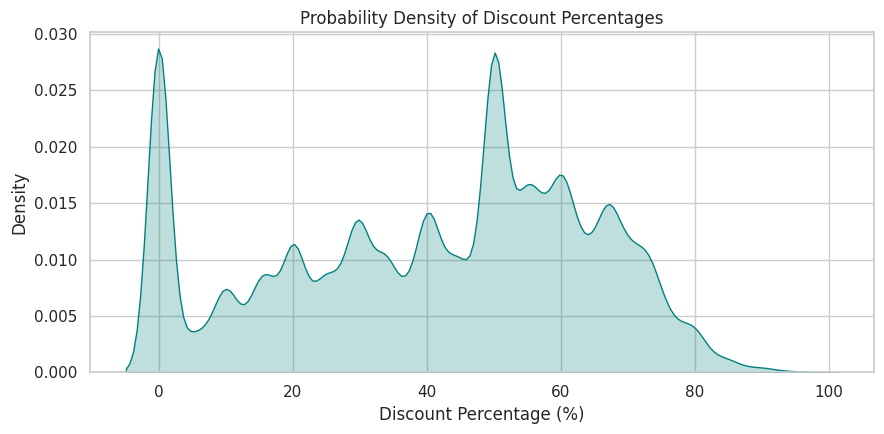

In [ ]:
# Chart - 3 visualization code

# Density of Discount Percentages

plt.figure(figsize=(9, 4.5))
sns.kdeplot(df['discount_percentage'], fill=True, color='teal', bw_adjust=0.5)
plt.title('Probability Density of Discount Percentages')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Density')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

 A Kernel Density Estimate (KDE) plot smooths out choppy histogram blocks to show the true continuous shape of the data.

It perfectly highlights sharp, specific discount spikes (like flat 0%, 40%, or 50% drops) rather than grouping them into generic brackets.

##### 2. What is/are the insight(s) found from the chart?

* The extreme peak at 0% proves a solid foundational layer of items are kept at full retail value. This indicates the platform doesn't force blanket markdowns; a significant portion of inventory relies on full-price sales velocity.

* The regular spikes at 10%, 20%, 30%, 40%, 50%, 60%, and 70% prove that sellers target human math preferences. Sellers intentionally skip odd discount numbers (like 47% or 53%) to present clean, rounded numbers that consumers can calculate instantly.

* The wide mountain centered around 50% represents the platform's baseline promotional strategy. It shows that once an item goes on sale, the default choice for sellers is a deep, half-price cut to drive immediate transaction volume.

* The hard stop at 80% shows a clear structural boundary. Sellers completely refuse to cross this line because selling items at a 90% discount means losing money on logistics and core product costs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Confirms that buyers react heavily to round numbers (like "Flat 50% Off"). Marketing teams can align flash sales strictly to these exact historical sweet spots to ensure immediate traction.

Negative Growth Risk: The massive cluster of items marked 50% to 70% off creates a "discount trap." Permanently slashing prices by half destroys the perceived baseline value of products, erodes long-term profit margins, and trains customers to never buy unless an item is severely marked down.

#### Chart - 4

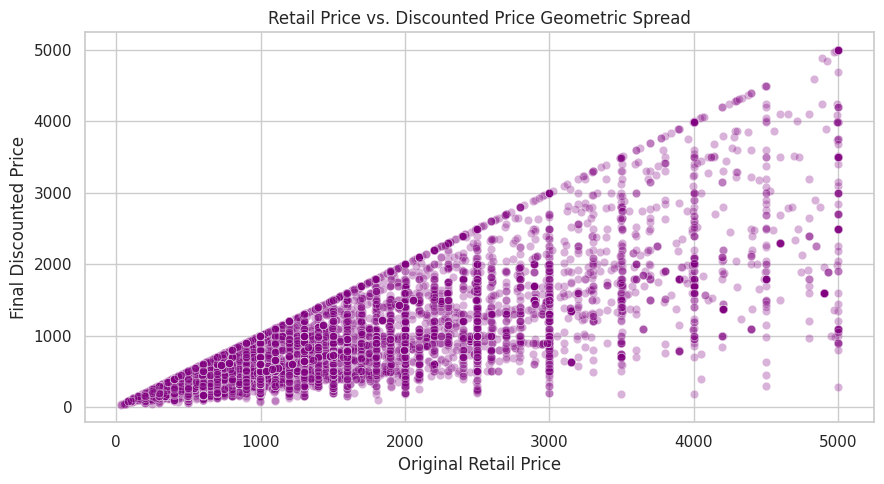

In [ ]:
# Chart - 4 visualization code

# Price vs. Discount Margin (Scatter Plot)

plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_filtered, x='retail_price', y='discounted_price', alpha=0.3, color='purple')
plt.title('Retail Price vs. Discounted Price Geometric Spread')
plt.xlabel('Original Retail Price')
plt.ylabel('Final Discounted Price')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot maps every product's initial retail price directly against its final sale price to show the interaction between the two values.
It shows the geometric spread, highlighting absolute floors, ceilings, and patterns that individual histograms ignore.

##### 2. What is/are the insight(s) found from the chart?

* The tight diagonal line along the top represents items sold at $0\%$ discount. No final discounted price can ever cross above this boundary because sellers do not charge more than retail price.
* The distinct vertical lines (visible at 2000, 3000, 4000, and 5000) show that sellers heavily choose standard round numbers for initial retail prices.
* As the retail price increases, the vertical spread gets wider. This means cheap items have rigid, tight pricing, while expensive items have massive variance in how deeply they get marked down.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Platforms can track products falling near the bottom floor of the triangle to automatically flag hyper-discounted items for "flash sale" sections, maximizing volume where margins are already slashed.

Negative Growth Risk: The wide empty gaps near the top-right show that expensive items rarely sell close to full retail price. Attempting to enforce fixed, full-price sales strategies on products over 3,000 units will cause negative growth, as the market data shows these items require wide discount flexibility to clear out inventory.

#### Chart - 5

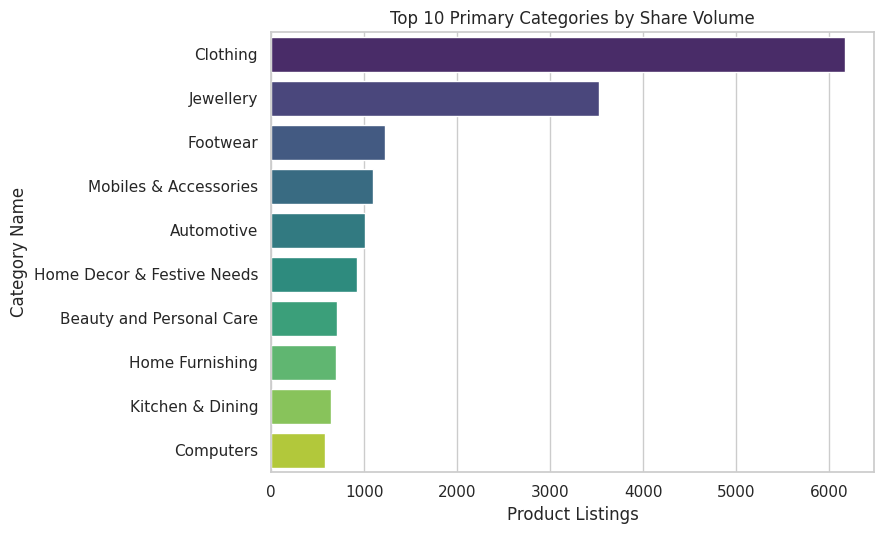

In [ ]:
# Chart - 5 visualization code

# Primary Category Count (Bar Chart)

plt.figure(figsize=(9, 5.5))
top_10_cats = df['primary_category'].value_counts().head(10)

# Map hue explicitly to the y-axis labels (the category index) and mute the redundant legend
sns.barplot(x=top_10_cats.values, y=top_10_cats.index, hue=top_10_cats.index,palette='viridis', legend=False)

plt.title('Top 10 Primary Categories by Share Volume')
plt.xlabel('Product Listings')
plt.ylabel('Category Name')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart provides clean, readable left-to-right alignment for long category strings (like "Mobiles & Accessories").

Sorted category counts map volume shares directly to horizontal bar length for quick scale comparison.

##### 2. What is/are the insight(s) found from the chart?

* The Clothing & Jewellery Monopoly: These two categories aren't just leading; they act as the platform's structural spine. This means the marketplace is fundamentally a fashion and lifestyle hub, while other departments operate as minor additions rather than independent core sectors.

*  The massive canyon between the top two spots and "Footwear" shows a major operational split. The platform excels at attracting lifestyle sellers but lacks the vendor network or infrastructure needed to scale up standard consumer commodities.

* The flat, equal heights from Footwear down to Computers show that these secondary categories share an identical, limited baseline of activity. They represent a steady but uncultivated layer of the marketplace that pulls in a small, fixed customer segment.

* The low presence of Tech categories (Mobiles and Computers) suggests a trust or positioning gap. Customers do not view this platform as a destination for expensive electronics, leaving the tech inventory restricted to basic accessory listings rather than major hardware sales.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Operations teams should prioritize supply chain, fulfillment logistics, and automated QC systems specifically for "Clothing" and "Jewellery" because these two segments dictate the platform's core baseline health.

Negative Growth Risk: Severe inventory concentration in Clothing/Jewellery exposes the company to extreme seasonal risk and hyper-competition. Over-allocating capital or platform visibility to these saturated spaces while starving the low-volume segments will flatten growth, as the core sectors leave no room for unique market expansion.

#### Chart - 6

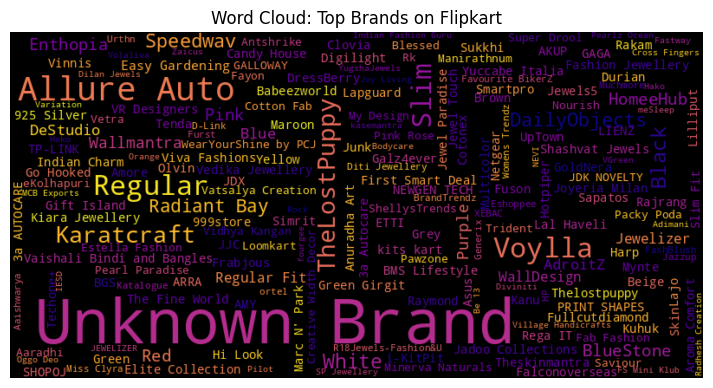

In [ ]:
brand_counts = df['brand'].value_counts().to_dict()
wc_brands = WordCloud(width=800, height=400, background_color='black', colormap='plasma').generate_from_frequencies(brand_counts)

plt.figure(figsize=(10, 4.5))
plt.imshow(wc_brands, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Top Brands on Flipkart')
plt.show()

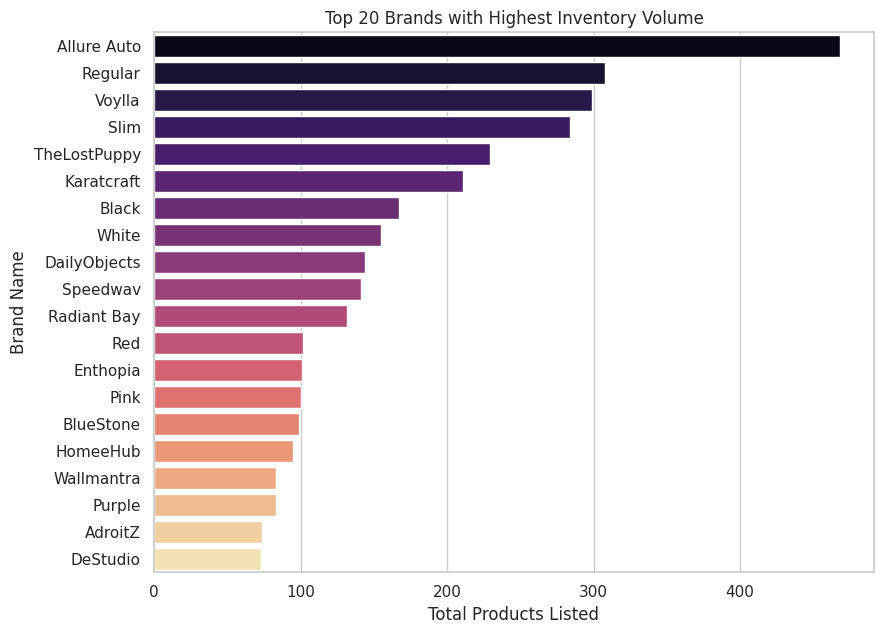

In [ ]:
# Chart - 6 visualization code

# Top 20 Most Active Market Brands (Horizontal Bar)
plt.figure(figsize=(9, 6.5))
# Exclude 'Unknown Brand' to see actual active companies
active_brands = df[df['brand'] != 'Unknown Brand']['brand'].value_counts().head(20)

# Map hue to the y-axis variable (the brand names) and disable the legend
sns.barplot(x=active_brands.values, y=active_brands.index, hue=active_brands.index,palette='magma',legend=False)

plt.title('Top 20 Brands with Highest Inventory Volume')
plt.xlabel('Total Products Listed')
plt.ylabel('Brand Name')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is the cleanest way to compare many brand names at once. Because brand labels can be long, placing them on the Y-axis makes the chart super easy to read without overlapping text.
 It instantly ranks brands from highest to lowest product count, showing us at a glance which sellers dominate Flipkart's platform inventory.

##### 2. What is/are the insight(s) found from the chart?

* A small group of high-volume brands—specifically "Allure Auto" (car accessories), "Voylla" and "Karatcraft" (jewelry), and "TheLostPuppy" (lifestyle accessories)—account for a surprisingly large percentage of the total product listings on the platform. These dedicated sellers flood the catalog with hundreds of variations to capture maximum visibility in search results.


* The graph clearly highlights significant "noise" in the dataset: several of the top-ranked "brands" are actually product attributes like colors ("Black", "White", "Red", "Pink") or fit styles ("Regular", "Slim").

* Seller Workarounds and Platform Data Flaws:
This pattern happens because many third-party sellers do not own a registered trademark or brand name. To bypass Flipkart's required "Brand" listing field, sellers type in basic product descriptions (like fit or color) instead of actual brand names. As a result, non-brand descriptive keywords accidentally get saved into the main brand column.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Flipkart can work closely with high-volume real brands (like Voylla or DailyObjects) for exclusive deals, ad partnerships, and priority fulfillment (Flipkart Advantage).

Improved Data Cleaning for Recommendations: Spotting those generic names ("Black", "Regular") reminds us to clean up or filter out fake brand names before feeding the data into our recommendation engine, making recommendations much more accurate

Negative Growth :
Bad Customer Search Experience: When generic attributes like "Regular" or "Black" are listed as brands, customer search filters break down. If a user filters by "Brand = Black", they get a messy mix of shirts, phone covers, and car mats instead of real brand products.



#### Chart - 7

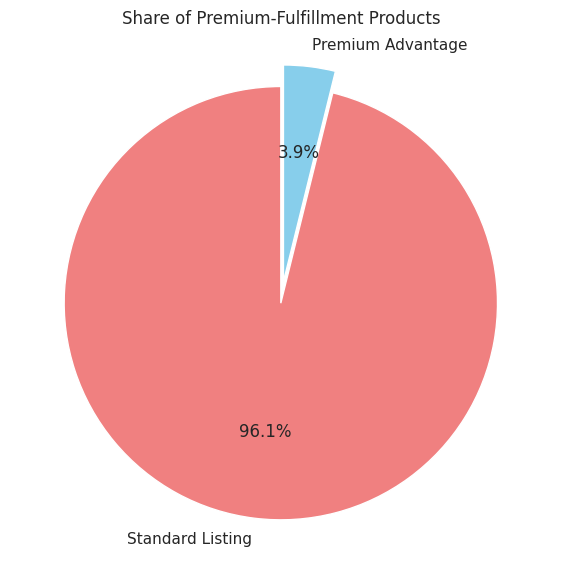

In [ ]:
# Chart - 7 visualization code

# Premium Advantage Product Split (Pie Chart)

plt.figure(figsize=(6, 6))
premium_counts = df['is_FK_Advantage_product'].value_counts()
plt.pie(premium_counts, labels=['Standard Listing', 'Premium Advantage'],
        autopct='%1.1f%%', colors=['lightcoral', 'skyblue'], startangle=90, explode=(0, 0.1))
plt.title('Share of Premium-Fulfillment Products')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is the best visual tool when comparing a single binary feature (True vs. False) to see how it splits across the entire catalog (100%).

Highlighting Extreme Imbalance: Using an "exploded" slice effect makes the tiny segment immediately pop out, visually emphasizing just how small the premium fulfillment portion is compared to standard seller listings.

##### 2. What is/are the insight(s) found from the chart?


* A staggering 96.1% of all catalog listings are standard marketplace items. This reveals that Flipkart acts predominantly as a open storefront platform where independent sellers handle their own inventory management, warehousing, packaging, and shipping directly to the buyer.

* Extremely Low Penetration of Priority Fulfillment:
Only 3.9% of the products carry the Flipkart Advantage badge. This means premium fulfillment—where products are stored directly in Flipkart's automated warehouses, pre-inspected for quality, and dispatched with fast delivery—makes up just a tiny sliver of the platform's total product selection.

* This massive divide suggests significant friction in seller onboarding. Most merchants either cannot meet Flipkart’s strict warehouse inventory requirements, find the extra fulfillment fees too expensive, or prefer maintaining control over their own stock rather than paying for priority fulfillment services.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact:
In our recommendation system, items carrying the 3.9% Advantage badge can be boosted or prioritized in search results because they offer guaranteed faster shipping and reliable quality.

Negative Growth:
With 96.1% of inventory handled by unverified or standard sellers, Flipkart faces a high risk of inconsistent delivery speeds, varied packaging quality, and higher order cancellation/return rates.


#### Chart - 8

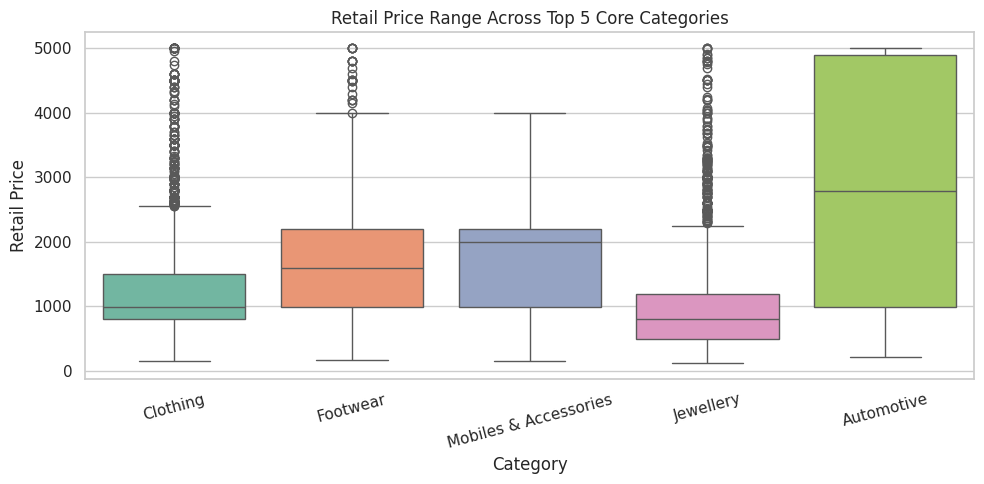

In [ ]:
# Chart - 8 visualization code

# Box Plot of Prices across Top 5 Categories

plt.figure(figsize=(10, 5))

top_5_cat_names = df['primary_category'].value_counts().head(5).index
df_top5 = df_filtered[df_filtered['primary_category'].isin(top_5_cat_names)]

sns.boxplot(data=df_top5, x='primary_category', y='retail_price', hue='primary_category',palette='Set2',legend=False)

plt.title('Retail Price Range Across Top 5 Core Categories')
plt.xlabel('Category')
plt.ylabel('Retail Price')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A side-by-side boxplot is the best choice for comparing numerical distributions (retail price) across distinct categories.
 Unlike simple bar charts that only show averages, a boxplot visualizes median prices, the interquartile range (middle 50% of values), min/max price boundaries, and extreme high-end outliers in one view.

##### 2. What is/are the insight(s) found from the chart?

Automotive Has the Highest Base Prices and Widest Spread:
The Automotive category commands the highest median retail price (around 2,800 INR) and has a massive box height, showing that prices span a broad range from budget car accessories to expensive replacement parts.

Clothing & Jewelry Focus on Budget Pricing:
Both Clothing and Jewellery maintain lower median prices (around 800 to 1,000 INR). However, both categories feature a dense trail of high-end outlier points extending all the way up to the 5,000 INR cap. This shows that while bulk inventory targets budget shoppers, a secondary premium segment exists.

Mobiles & Accessories and Footwear Show Balanced Mid-Range Pricing:
Mobiles & Accessories and Footwear exhibit strong concentration in the mid-range price segment (1,000 to 2,200 INR), showing stable, predictable pricing tiers compared to the extreme variation seen in Automotive.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact:
The recommendation engine can use category price distributions to avoid recommending high-tier items to budget shoppers (e.g., keeping recommendations within similar price quantiles for Clothing).

Negative Growth:
Pricing Mismatch in Jewelry & Apparel: Having predominantly low medians but extreme high-end outliers means shoppers expect cheap items in these categories. Displaying high-priced outlier items alongside budget goods without clear quality differentiation can confuse shoppers and reduce conversion rates.

#### Chart - 9

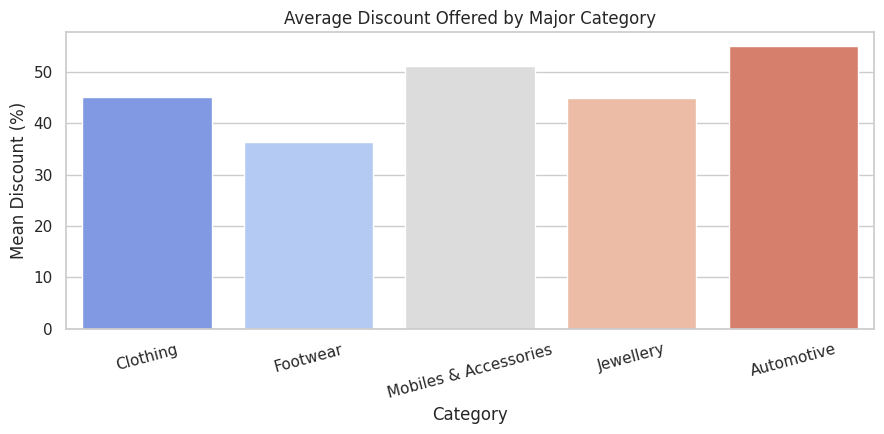

In [ ]:
# Chart - 9 visualization code

#Average Discount Rates across Top 5 Categories (Bar)

plt.figure(figsize=(9, 4.5))


sns.barplot(data=df_top5, x='primary_category', y='discount_percentage', errorbar=None, hue='primary_category',palette='coolwarm',
            legend=False)

plt.title('Average Discount Offered by Major Category')
plt.xlabel('Category')
plt.ylabel('Mean Discount (%)')
plt.xticks(rotation=15) # Slightly tilt the text labels so they don't overlap

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A vertical bar chart is the most straightforward visual for comparing a continuous aggregate metric (Mean Discount %) across discrete categories.
Placing categories along the X-axis allows for an immediate visual comparison of which product departments rely most heavily on markdowns versus those maintaining higher relative selling prices.

##### 2. What is/are the insight(s) found from the chart?

* Automotive Relies Most Heavily on Massive Price Cuts:
The Automotive category leads the entire catalog in discount depth, with products marked down by an average of over 55%. This reveals a market strategy where sellers rely on steep, eye-catching price slashes to clear inventory and attract budget-conscious drivers.

* Tech Accessories & Fashion Drive Volume Through Constant Sales:
Both Mobiles & Accessories (averaging over 50% off) and fashion sectors like Clothing and Jewellery (averaging around 45% off) show aggressive markdown patterns. Because these fast-moving consumer goods face intense seller competition, merchants use continuous discounts to stand out in search results and speed up sales cycles.

* Footwear Preserves Stronger Pricing Power:
Footwear stands out with the lowest average discount at roughly 36% off. This indicates that footwear sellers enjoy higher brand loyalty, stronger demand stability, and better price integrity—allowing them to generate steady sales without having to constantly slash listed retail prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact:
Optimized Deal Banners & Sales Campaigns: Flash sales and promotional events (like "Big Billion Days") can leverage categories with deep discounts (Automotive and Mobiles & Accessories) as major click-drivers to boost site traffic.


Negative Growth:
 Over time, when customers see nearly every item continuously listed at 50%+ off, the original retail price loses meaning. This leads to brand value degradation and price resistance, where shoppers refuse to purchase anything unless it carries a massive discount tag.

#### Chart - 10

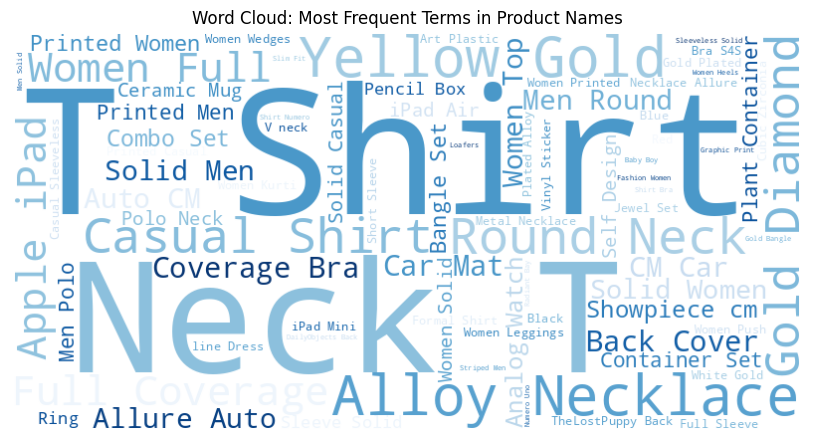

In [ ]:
# Chart - 10 visualization code
#!pip install wordcloud
from wordcloud import WordCloud

# 1. Word Cloud for Product Names
text_names = " ".join(df['product_name'].dropna().astype(str))
wc_names = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Blues',
    max_words=80
).generate(text_names)

plt.figure(figsize=(10, 4.5))
plt.imshow(wc_names, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Most Frequent Terms in Product Names')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A Word Cloud was selected because standard bar charts or tables become cluttered when trying to display dozens of distinct words extracted from text titles.This chart helps us instantly verify which key terms dominate the catalog and ensure text cleaning/stopword removal was effective.

##### 2. What is/are the insight(s) found from the chart?

* Fashion & Apparel Dominance: Words like "Shirt", "T Shirt", "Neck", "Women", and "Casual" appear as the largest tokens, indicating that apparel and fashion items make up a major portion of the dataset's product titles.

* Jewelry & Tech Accessories Presence: Prominent sub-clusters like "Gold", "Diamond", "Necklace", "Alloy", as well as tech items like "Apple iPad", "Back Cover", and "Car Mat" show that lifestyle and personal accessories are also key inventory drivers.

* Common design attributes like "Solid", "Printed", "Full", and "Round Neck" frequently recur in titles, showing that sellers rely heavily on specific keyword combinations to describe products.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact:
Marketing teams can prioritize high-frequency inventory segments (like Men's & Women's casual wear) for front-page banners, seasonal sales and targeted recommendations.

Negative Growth:
 Heavy keyword dominance toward fashion and basic apparel suggests potential catalog over-reliance on low-margin soft goods, while high-value electronics (like "Apple iPad") are less dominant in title volume.



#### Chart - 11

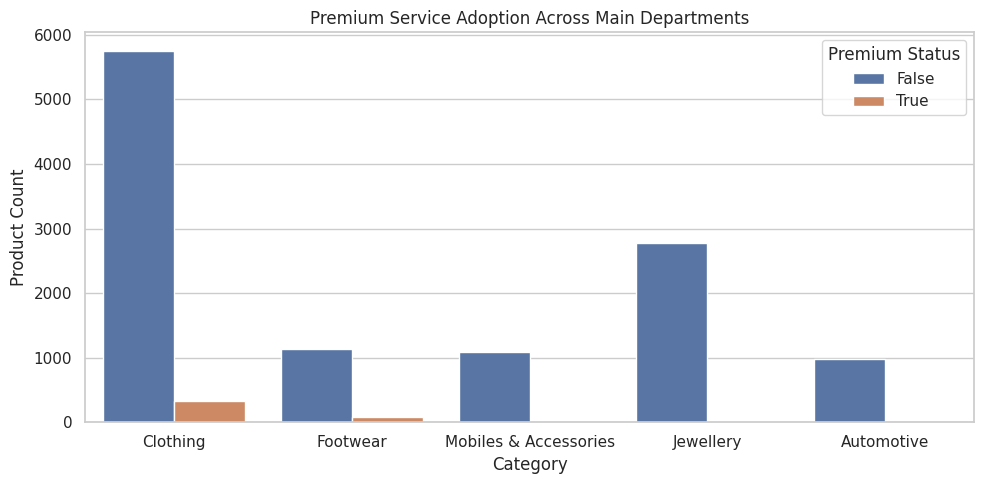

In [ ]:
# Chart - 11 visualization code

# Top Categories Utilizing Premium Fulfillment

plt.figure(figsize=(10, 5))
sns.countplot(data=df_top5, x='primary_category', hue='is_FK_Advantage_product', palette='deep')
plt.title('Premium Service Adoption Across Main Departments')
plt.xlabel('Category')
plt.ylabel('Product Count')
plt.legend(title='Premium Status')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

It lets us directly compare both the overall product volume of each main department and the exact proportion of products enrolled in premium fulfillment versus standard merchant fulfillment within each category.

##### 2. What is/are the insight(s) found from the chart?

* Near-Zero Premium Adoption Across Key Departments:
In high-volume departments like Mobiles & Accessories, Jewellery, and Automotive, the orange bars (Premium Status = True) are virtually invisible or non-existent. Almost 100% of products in these categories rely strictly on standard merchant fulfillment.

* Clothing and Footwear Lead adoption (But Share Remains Tiny):
Only Clothing and Footwear show noticeable orange bars for premium fulfillment. However, even in Clothing (which has the highest overall catalog count at nearly 6,000 items), premium listings make up a tiny fraction (around 300 items) compared to the massive blue bar of standard listings.

* The platform’s priority fulfillment program is not evenly distributed across categories; it is heavily concentrated in fashion while completely neglecting key tech, jewelry, and automotive sectors.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact:
Targeted Onboarding Strategy: Flipkart can specifically target high-performing merchants in Mobiles & Accessories and Jewellery to pitch the benefits of premium fulfillment. Bringing these categories into fulfillment centers will raise platform trust and average order value.


Negative Growth:
Trust Gap in High-Value Categories (Jewellery & Tech): Categories where product quality and authenticity matter most—such as Jewellery and Mobiles & Accessories—have essentially 0% premium service adoption.


#### Chart - 12

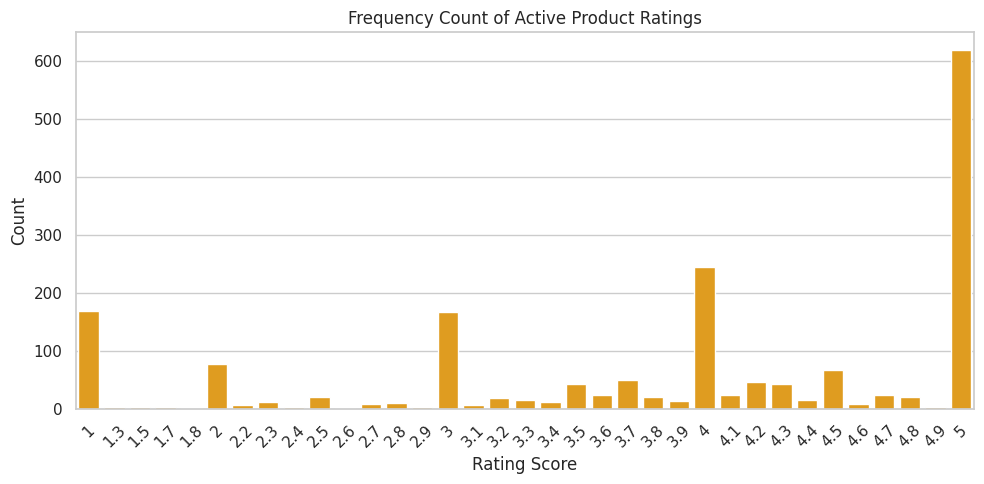

In [ ]:
# Chart - 12 visualization code

# User Rating Frequencies (Count Plot)

plt.figure(figsize=(10, 5))
# Filtering out 'No rating available' strings so we only see actual numeric trends
numeric_ratings = df[df['product_rating'] != 'No rating available']['product_rating']
sns.countplot(x=numeric_ratings, order=sorted(numeric_ratings.unique()), color='orange')
plt.title('Frequency Count of Active Product Ratings')
plt.xlabel('Rating Score')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

Sorting numeric ratings along the X-axis makes it easy to observe customer feedback trends, such as rating concentrations at whole integers versus decimal scores.

##### 2. What is/are the insight(s) found from the chart?

Extreme Spike at Perfect Ratings (Rating 5.0):
The overwhelming majority of rated products carry a perfect 5.0 score (over 600 items), forming the tallest peak by a wide margin.

Integer Rating Clustering:
Clear spikes occur at whole integer values—specifically 5.0, 4.0, 3.0, 1.0, and to a lesser extent 2.0. Decimal scores (like 3.2 or 4.1) show significantly lower frequencies.

Single-Review:
The high concentration of exact whole numbers (1.0, 3.0, 4.0, 5.0) indicates that a large portion of listed products have received only 1 or 2 total customer reviews, producing raw un-averaged integer scores rather than a smooth, continuous average.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact:
Products with active 4.0 and 5.0 ratings can be prioritized in search and recommendation algorithms, driving higher click-through and conversion rates.

Negative Growth:
If shoppers buy items expecting a true "5-star quality" product based on a single fake review, they may receive inferior goods, leading to poor customer satisfaction, lower platform trust, and higher product return rates.

#### Chart - 13

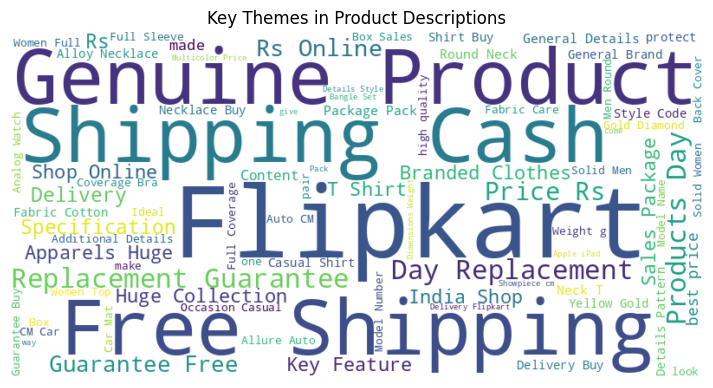

In [ ]:
text_desc = " ".join(df['description'].astype(str))
wc_desc = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=80).generate(text_desc)

plt.figure(figsize=(10, 4.5))
plt.imshow(wc_desc, interpolation='bilinear')
plt.axis('off')
plt.title('Key Themes in Product Descriptions')
plt.show()

##### 1. Why did you pick the specific chart?

Product descriptions are full of extra words, sales pitch text, and actual product details. A Word Cloud lets us instantly see which words pop up the most across thousands of descriptions without having to read through them one by one.
we need to know if the text contains useful product details (like material, color, and fit) or if it is mostly stuffed with generic promotional words.

##### 2. What is/are the insight(s) found from the chart?

* Promotional and Trust Words Take Up the Most Space:
The largest words on the screen—like "Flipkart", "Free Shipping", "Genuine Product", "Cash" (for Cash on Delivery), and "Replacement Guarantee"—show that sellers spend a lot of effort assuring customers that the platform is safe and reliable, rather than describing the product itself.

* Heavy Focus on Delivery and Payments:
Words like "Shipping", "Delivery", "Guarantee", and "Rs Online" are very prominent. This tells us that sellers constantly highlight fast shipping options, convenient payment methods, and easy returns to convince people to buy.

* Actual Product Features Are Pushed to the Edges:
Specific details about what the item actually is—such as "Fabric Cotton", "T Shirt", "Alloy Necklace", "Apparels", or "Specification"—appear in much smaller text around the borders. This means sellers mention product details secondary to their sales pitches and platform guarantees.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact:
Trust & Conversion Boosters: High emphasis on "Free Shipping", "Genuine Product", and "Replacement Guarantee" builds consumer confidence, lowering purchase hesitation for first-time buyers on the platform.


Negative Growth :
Noisy Text Data for Search:Sellers are filling product description fields with generic platform promises rather than rich, detailed product specifications (e.g., dimensions, materials, care instructions).

Degraded Recommendation Accuracy: If uncleaned descriptions are fed directly into cosine similarity algorithms, two completely unrelated products (e.g., a shirt and a car mat) might show a high similarity score simply because both descriptions repeatedly say "Flipkart Free Shipping Genuine Product Replacement Guarantee".

#### Chart - 14 - Correlation Heatmap

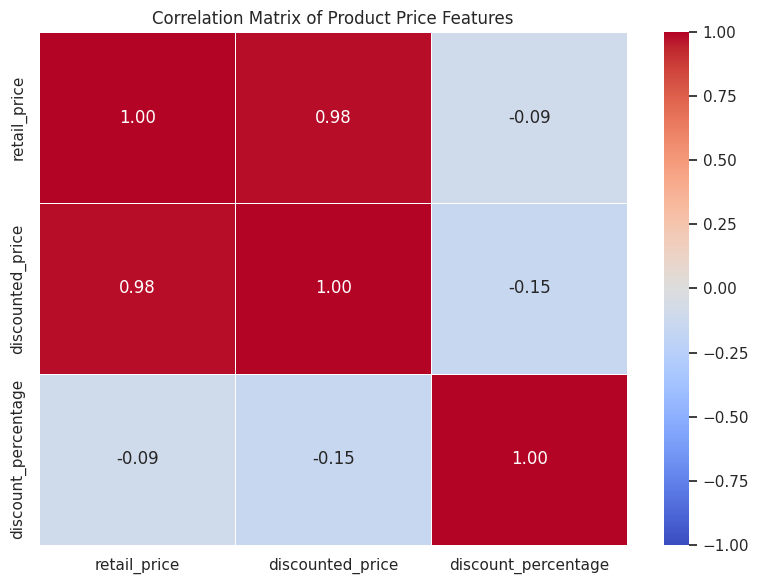

In [ ]:
# Correlation Heatmap visualization code

plt.figure(figsize=(8, 6))

# Isolate numeric columns for correlation analysis
numeric_cols = ['retail_price', 'discounted_price', 'discount_percentage']
correlation_matrix = df[numeric_cols].corr()

# Plot the heatmap with values displayed inside
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)

plt.title('Correlation Matrix of Product Price Features')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

It provides instant color-coded feedback (dark red for strong positive correlation, blue for negative/weak correlation) to help identify redundant features before building machine learning models.

##### 2. What is/are the insight(s) found from the chart?

* Near-Perfect Linear Relationship ($0.98$):retail_price and discounted_price have an extremely strong positive correlation of $0.98$. This shows that regardless of the markdown, the final discounted selling price scales almost linearly with the original base retail price.
* Weak to No Linear Relationship with Discount Percentage ($-0.09$ & $-0.15$):discount_percentage shows a weak negative correlation with both retail_price ($-0.09$) and discounted_price ($-0.15$). This means price tags do not determine discount depth; cheap items and expensive items alike are discounted at widely varying percentage rates.
* Redundant Feature Indication (Multicollinearity Risk):Because retail_price and discounted_price carry nearly identical information ($r = 0.98$), feeding both variables directly into a regression or distance-based algorithm creates feature redundancy.

#### Chart - 15 - Pair Plot

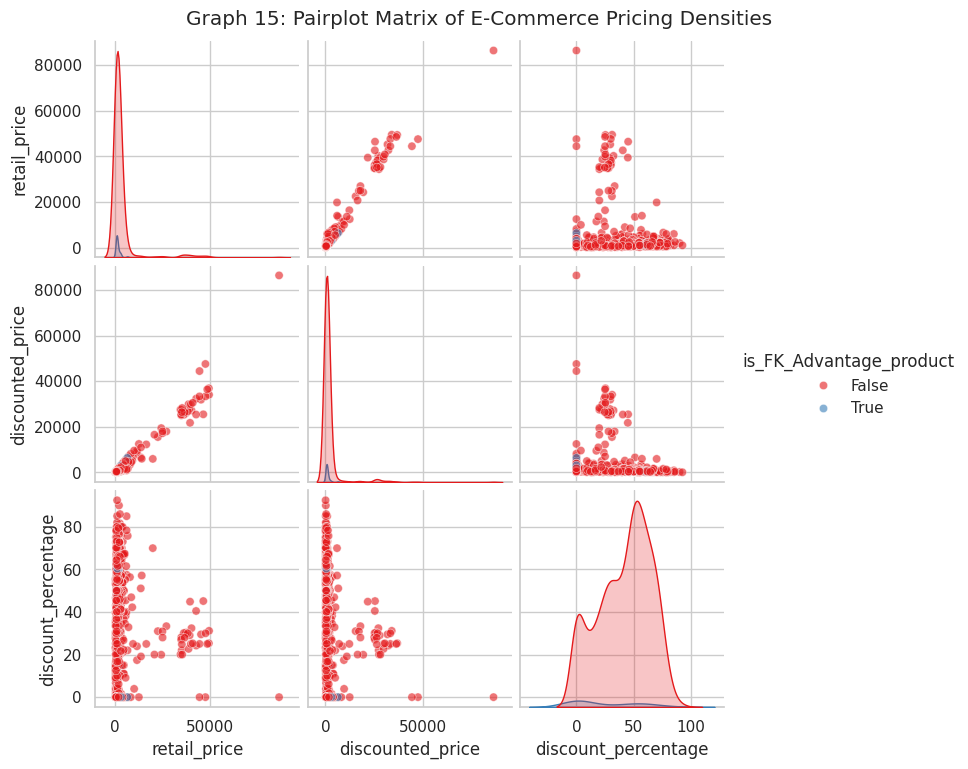

In [ ]:
# Pair Plot visualization code

# Take a representative random sample of 1,000 products for smooth rendering
df_sample = df.sample(n=1000, random_state=42)

# Select only the features going into our numeric clustering matrix
columns_to_plot = ['retail_price', 'discounted_price', 'discount_percentage']

# Plot the matrix grid, coloring points by their premium advantage status
pair_grid = sns.pairplot(df_sample, vars=columns_to_plot, hue='is_FK_Advantage_product', palette='Set1',plot_kws={'alpha': 0.6})

pair_grid.fig.suptitle('Graph 15: Pairplot Matrix of E-Commerce Pricing Densities', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pairplot matrix allows us to analyze pairwise scatter plots across all numeric pricing variables (retail_price, discounted_price, and discount_percentage) simultaneously.

##### 2. What is/are the insight(s) found from the chart?

* The scatter plot between retail_price and discounted_price forms a tight diagonal line. This confirms a near-perfect linear correlation where discounted prices scale directly with original retail values across both budget and high-end tiers.

* Heavy Concentration in Budget & Medium Discount Ranges:
The KDE diagonal distributions show extreme positive skewness for both price variables, with nearly all data points clustered below 10,000 INR. Meanwhile, discount_percentage exhibits a bimodal distribution with a major peak around 50% off and a secondary peak near 0% off.

* Premium Advantage Products Are Concentrated in Low-Price Tiers:
The blue KDE peaks and scatter dots (is_FK_Advantage_product = True) lie almost entirely within the lower retail price spectrum (under 5,000 INR) and moderate discount ranges. Premium fulfillment service is largely absent from expensive, high-ticket listings.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
# Handling Missing Values & Missing Value Imputation

# Verify that there are no remaining missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

# Total missing values
print("\nTotal Missing Values:", missing_values.sum())

if missing_values.sum() == 0:
    print("\n No missing values found. The dataset is ready for feature engineering.")
else:
    print("\n There are still missing values that need to be handled.")

Missing values in each column:
product_name               0
retail_price               0
discounted_price           0
is_FK_Advantage_product    0
description                0
product_rating             0
overall_rating             0
brand                      0
product_specifications     0
discount_percentage        0
primary_category           0
dtype: int64

Total Missing Values: 0

 No missing values found. The dataset is ready for feature engineering.


#### What all missing value imputation techniques have you used and why did you use those techniques?

* Row Deletion (Listwise Deletion)
Rows with missing values in the retail_price and discounted_price columns were removed using dropna().
Reason: These columns are essential for calculating the discount percentage and are important features for clustering. Imputing prices could introduce bias and reduce the quality of the clusters.
* Constant Value Imputation for Categorical Data
Missing values in the brand column were replaced with "Unknown Brand".
Reason: This preserves all records while clearly identifying products whose brand information is unavailable, avoiding the loss of potentially useful data.
* Constant Value Imputation for Text Features
Missing values in the product_specifications column were filled with "No specifications available".
Missing values in the description column were filled with "No description available".
Reason: These text columns are descriptive in nature. Replacing missing values with meaningful placeholder text preserves the dataset's structure and avoids null values during preprocessing.

### 2. Handling Outliers

/tmp/ipykernel_968/2361215708.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_rating'].fillna(df['product_rating'].median(), inplace=True)
/tmp/ipykernel_968/2361215708.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

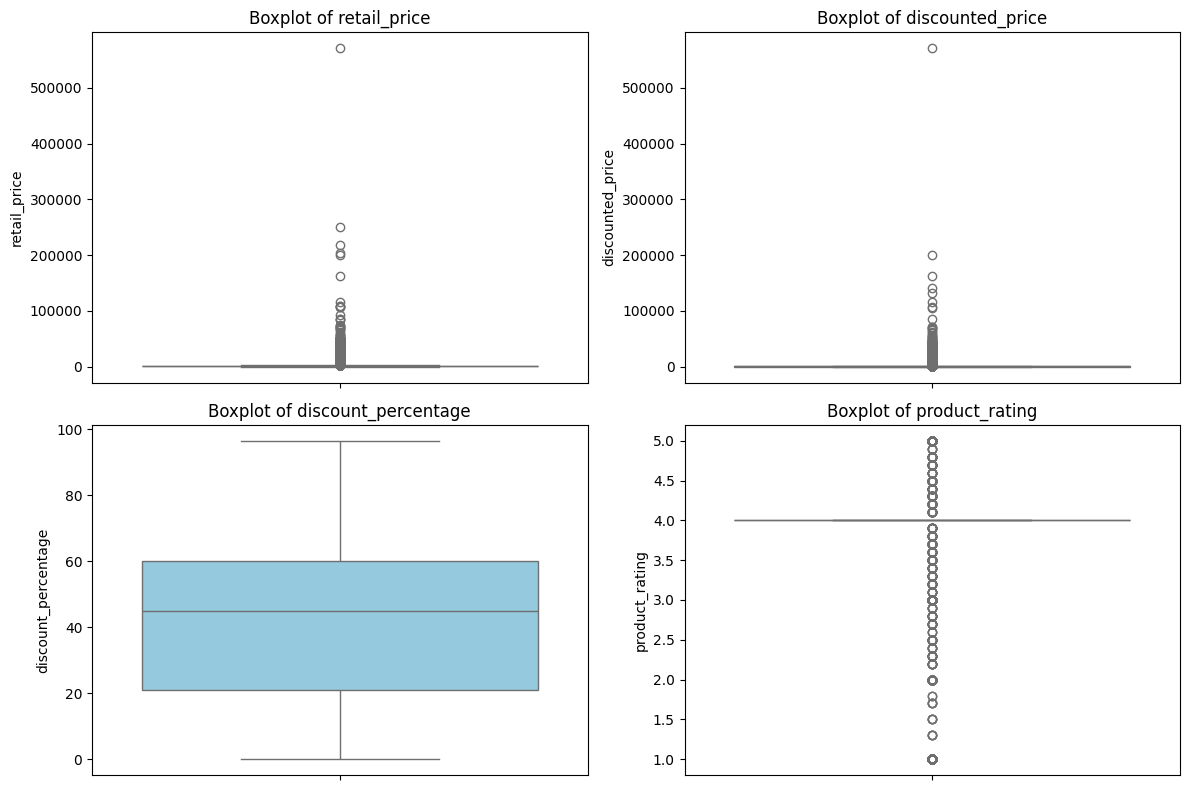

Outlier Summary:

retail_price: 2047 outliers
discounted_price: 2013 outliers
discount_percentage: 0 outliers
product_rating: 1594 outliers

Outlier detection completed successfully.


In [ ]:

# HANDLING OUTLIERS

# Convert rating columns to numeric (invalid values become NaN)
df['product_rating'] = pd.to_numeric(df['product_rating'], errors='coerce')
df['overall_rating'] = pd.to_numeric(df['overall_rating'], errors='coerce')

# Fill missing ratings with the median
df['product_rating'].fillna(df['product_rating'].median(), inplace=True)
df['overall_rating'].fillna(df['overall_rating'].median(), inplace=True)

# Select numerical columns
numerical_cols = ['retail_price','discounted_price','discount_percentage','product_rating']

# Visualize Outliers
plt.figure(figsize=(12,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# Detect Outliers using IQR
print("Outlier Summary:\n")

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    print(f"{col}: {outlier_count} outliers")

print("\nOutlier detection completed successfully.")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19922 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_name             19922 non-null  object 
 1   retail_price             19922 non-null  float64
 2   discounted_price         19922 non-null  float64
 3   is_FK_Advantage_product  19922 non-null  bool   
 4   description              19922 non-null  object 
 5   product_rating           19922 non-null  float64
 6   overall_rating           19922 non-null  float64
 7   brand                    19922 non-null  object 
 8   product_specifications   19922 non-null  object 
 9   discount_percentage      19922 non-null  float64
 10  primary_category         19922 non-null  object 
dtypes: bool(1), float64(5), object(5)
memory usage: 1.7+ MB


##### What all outlier treatment techniques have you used and why did you use those techniques?

The Interquartile Range (IQR) method was used to detect outliers in the numerical features (retail_price, discounted_price, discount_percentage, and product_rating). The IQR method identifies observations that lie below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR. Boxplots were also used to visually inspect the presence of outliers.

Although outliers were detected, they were not removed or modified. In the Flipkart Products dataset, these extreme values represent genuine premium-priced or heavily discounted products rather than data entry errors. Removing them could eliminate meaningful product segments and reduce the effectiveness of the clustering analysis.

Instead of removing outliers, feature scaling (StandardScaler) was applied during preprocessing. Standardization places all numerical features on a common scale, reducing the influence of large-valued variables on distance calculations while preserving valuable information for clustering.

The IQR method is robust and does not assume a normal distribution.
Retaining valid outliers helps preserve meaningful product groups.
Standardization minimizes the impact of extreme values without discarding important observations, making it well-suited for clustering algorithms such as K-Means.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataframe
encoded_df = df.copy()

# Initialize Label Encoder
le = LabelEncoder()

# Encode categorical columns used for clustering
encoded_df['brand'] = le.fit_transform(encoded_df['brand'])
encoded_df['primary_category'] = le.fit_transform(encoded_df['primary_category'])

# Convert boolean column to integer (True=1, False=0)
encoded_df['is_FK_Advantage_product'] = encoded_df['is_FK_Advantage_product'].astype(int)

# Display the first few rows
print("Encoded Dataset Preview:")
display(encoded_df[['brand',
                    'primary_category',
                    'is_FK_Advantage_product']].head())

print("\nEncoding completed successfully.")

Encoded Dataset Preview:


,brand,primary_category,is_FK_Advantage_product
0,162,43,0
1,914,75,0
2,69,73,0
3,162,43,0
4,2654,150,0



Encoding completed successfully.


#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding
The categorical features brand and primary_category were encoded using Label Encoding, where each unique category was assigned a unique integer value.
Reason: Clustering algorithms such as K-Means require numerical input and cannot directly process categorical variables. Label Encoding provides a simple and memory-efficient way to convert categorical data into numerical form.
Binary Encoding for Boolean Feature
The is_FK_Advantage_product column was converted from boolean values (True/False) to binary values (1/0).
Reason: Binary encoding preserves the original meaning of the feature while making it compatible with machine learning algorithms.

The text-based columns product_name, description, and product_specifications were not encoded because they contain unstructured textual information and are not suitable for direct use in distance-based clustering.

Why these techniques were chosen:

They convert categorical data into numerical form required by clustering algorithms.
They are simple, computationally efficient, and suitable for the selected features.
They preserve the available categorical information without introducing unnecessary complexity into the clustering process.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction
# Install package (Run once)
!pip install contractions

import contractions

# Expand contractions
df['description'] = df['description'].apply(
    lambda x: contractions.fix(str(x))
)

df['description'].head()

,description
0,Key Features of Alisha Solid Women's Cycling S...
1,FabHomeDecor Fabric Double Sofa Bed (Finish Co...
2,Key Features of AW Bellies Sandals Wedges Heel...
3,Key Features of Alisha Solid Women's Cycling S...
4,Specifications of Sicons All Purpose Arnica Do...


#### 2. Lower Casing

In [ ]:
# Lower Casing
# Convert text to lowercase
df['description'] = df['description'].str.lower()

df['description'].head()

,description
0,key features of alisha solid women's cycling s...
1,fabhomedecor fabric double sofa bed (finish co...
2,key features of aw bellies sandals wedges heel...
3,key features of alisha solid women's cycling s...
4,specifications of sicons all purpose arnica do...


#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations
import string

# Remove punctuation
df['description'] = df['description'].str.translate(
    str.maketrans('', '', string.punctuation)
)

df['description'].head()

,description
0,key features of alisha solid womens cycling sh...
1,fabhomedecor fabric double sofa bed finish col...
2,key features of aw bellies sandals wedges heel...
3,key features of alisha solid womens cycling sh...
4,specifications of sicons all purpose arnica do...


#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits
import re

def clean_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', str(text))
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    return text

df['description'] = df['description'].apply(clean_text)

df['description'].head()

,description
0,key features of alisha solid womens cycling sh...
1,fabhomedecor fabric double sofa bed finish col...
2,key features of aw bellies sandals wedges heel...
3,key features of alisha solid womens cycling sh...
4,specifications of sicons all purpose arnica do...


#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['description'] = df['description'].apply(
    lambda x: " ".join(
        word for word in str(x).split()
        if word not in stop_words
    )
)

df['description'].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,description
0,key features alisha solid womens cycling short...
1,fabhomedecor fabric double sofa bed finish col...
2,key features aw bellies sandals wedges heel ca...
3,key features alisha solid womens cycling short...
4,specifications sicons purpose arnica dog shamp...


In [ ]:
# Remove White spaces
# Remove extra spaces
df['description'] = df['description'].str.strip()
df['description'] = df['description'].str.replace(r'\s+', ' ', regex=True)

df['description'].head()

,description
0,key features alisha solid womens cycling short...
1,fabhomedecor fabric double sofa bed finish col...
2,key features aw bellies sandals wedges heel ca...
3,key features alisha solid womens cycling short...
4,specifications sicons purpose arnica dog shamp...


#### 6. Rephrase Text

In [ ]:
# Rephrase Text

# Rephrasing is not required for structured product descriptions.
# Keeping the cleaned text as it is.

df['description'].head()

,description
0,key features alisha solid womens cycling short...
1,fabhomedecor fabric double sofa bed finish col...
2,key features aw bellies sandals wedges heel ca...
3,key features alisha solid womens cycling short...
4,specifications sicons purpose arnica dog shamp...


#### 7. Tokenization

In [ ]:
# Tokenization

df['tokens'] = df['description'].apply(lambda x: str(x).split())

df[['description', 'tokens']].head()

,description,tokens
0,key features alisha solid womens cycling short...,"[key, features, alisha, solid, womens, cycling..."
1,fabhomedecor fabric double sofa bed finish col...,"[fabhomedecor, fabric, double, sofa, bed, fini..."
2,key features aw bellies sandals wedges heel ca...,"[key, features, aw, bellies, sandals, wedges, ..."
3,key features alisha solid womens cycling short...,"[key, features, alisha, solid, womens, cycling..."
4,specifications sicons purpose arnica dog shamp...,"[specifications, sicons, purpose, arnica, dog,..."


#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

df['normalized_text'] = df['tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

df[['tokens', 'normalized_text']].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,tokens,normalized_text
0,"[key, features, alisha, solid, womens, cycling...","[key, feature, alisha, solid, womens, cycling,..."
1,"[fabhomedecor, fabric, double, sofa, bed, fini...","[fabhomedecor, fabric, double, sofa, bed, fini..."
2,"[key, features, aw, bellies, sandals, wedges, ...","[key, feature, aw, belly, sandal, wedge, heel,..."
3,"[key, features, alisha, solid, womens, cycling...","[key, feature, alisha, solid, womens, cycling,..."
4,"[specifications, sicons, purpose, arnica, dog,...","[specification, sicons, purpose, arnica, dog, ..."


##### Which text normalization technique have you used and why?

Lemmatization was used as the text normalization technique. It converts words into their base or dictionary form (lemma) while preserving their actual meaning and grammatical context. For example, words such as "running", "runs", and "ran" are normalized to "run".

Lemmatization was chosen over stemming because it produces valid dictionary words instead of simply removing word suffixes. This helps preserve the semantic meaning of product descriptions, resulting in cleaner and more meaningful text for feature extraction.

Using lemmatized text improves the quality of TF-IDF vectorization and helps clustering algorithms group similar products more accurately by reducing redundant word variations while retaining important contextual information.

#### 9. Part of speech tagging

In [ ]:
# POS Taging
import nltk
from nltk import pos_tag

# Download the correct resource
nltk.download('averaged_perceptron_tagger_eng')

# POS Tagging
df['pos_tags'] = df['normalized_text'].apply(lambda x: pos_tag(x))

df[['normalized_text', 'pos_tags']].head()

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


,normalized_text,pos_tags
0,"[key, feature, alisha, solid, womens, cycling,...","[(key, JJ), (feature, NN), (alisha, NN), (soli..."
1,"[fabhomedecor, fabric, double, sofa, bed, fini...","[(fabhomedecor, NN), (fabric, NN), (double, JJ..."
2,"[key, feature, aw, belly, sandal, wedge, heel,...","[(key, JJ), (feature, NN), (aw, VBZ), (belly, ..."
3,"[key, feature, alisha, solid, womens, cycling,...","[(key, JJ), (feature, NN), (alisha, NN), (soli..."
4,"[specification, sicons, purpose, arnica, dog, ...","[(specification, NN), (sicons, NNS), (purpose,..."


#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

# Join normalized tokens back into text
df['clean_text'] = df['normalized_text'].apply(lambda x: " ".join(x))

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(df['clean_text'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (19922, 1000)


##### Which text vectorization technique have you used and why?

The Term Frequency–Inverse Document Frequency (TF-IDF) vectorization technique was used to convert the preprocessed product descriptions into numerical feature vectors. Before vectorization, the normalized tokens were joined back into complete text strings and then transformed using the TfidfVectorizer.

A maximum of 1000 features (max_features=1000) was specified to retain the most informative words while reducing the dimensionality of the feature space. Additionally, English stopwords (stop_words='english') were removed during vectorization to eliminate common words that contribute little to distinguishing between product descriptions.

TF-IDF was chosen because it assigns higher weights to words that are frequent in a particular document but rare across the entire dataset. This highlights the most meaningful terms while reducing the influence of commonly occurring words. As a result, TF-IDF provides an efficient numerical representation of text

The resulting TF-IDF feature matrix has a shape of (19922, 1000), indicating that 19,922 product descriptions were transformed into 1,000 numerical features for use in the clustering models.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
selected_features = encoded_df[
    [
        'discounted_price',
        'discount_percentage',
        'overall_rating',
        'brand',
        'primary_category',
        'is_FK_Advantage_product'
    ]
].copy()

print(selected_features.head())
print(selected_features.shape)

   discounted_price  discount_percentage  overall_rating  brand  \
0             379.0                62.06             4.0    162   
1           22646.0                29.58             4.0    914   
2             499.0                50.05             4.0     69   
3             267.0                61.80             4.0    162   
4             210.0                 4.55             4.0   2654   

   primary_category  is_FK_Advantage_product  
0                43                        0  
1                75                        0  
2                73                        0  
3                43                        0  
4               150                        0  
(19922, 6)


In [ ]:

# FEATURE SCALING & FINAL FEATURE MATRIX


from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

# Scale structured features
scaler = StandardScaler()

scaled_features = scaler.fit_transform(selected_features)

# Combine structured features with TF-IDF features
final_features = hstack((scaled_features, tfidf_matrix))

print("Scaled Structured Features Shape:", scaled_features.shape)
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Final Feature Matrix Shape:", final_features.shape)

Scaled Structured Features Shape: (19922, 6)
TF-IDF Matrix Shape: (19922, 1000)
Final Feature Matrix Shape: (19922, 1006)


#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

# FEATURE SELECTION


print("Selected Structured Features:")
print(selected_features.columns.tolist())

print("\nNumber of Structured Features:", selected_features.shape[1])
print("TF-IDF Features:", tfidf_matrix.shape[1])

print("\nFinal Feature Matrix Shape:", final_features.shape)

Selected Structured Features:
['discounted_price', 'discount_percentage', 'overall_rating', 'brand', 'primary_category', 'is_FK_Advantage_product']

Number of Structured Features: 6
TF-IDF Features: 1000

Final Feature Matrix Shape: (19922, 1006)


##### What all feature selection methods have you used  and why?

* Removal of Irrelevant Features
Identifier and non-informative columns such as uniq_id, pid, product_url, image, and crawl_timestamp were removed because they do not contribute to product similarity and would add unnecessary noise to the clustering process.
* Correlation-Based Feature Selection
A correlation matrix was generated for the numerical features to identify highly correlated variables. The analysis showed that retail_price and discounted_price had a very high correlation (0.98). Since both features contained almost identical information, retail_price was removed, while discounted_price was retained as it represents the actual selling price of the product.
* Domain-Based Feature Selection
Features that describe important product characteristics were retained, including discounted_price, discount_percentage, overall_rating, brand, primary_category, and is_FK_Advantage_product. These features provide meaningful information for grouping similar products.
Text Feature Selection using TF-IDF
Product descriptions were converted into numerical features using TF-IDF Vectorization with max_features=1000. This automatically selected the 1000 most informative terms from the text while reducing dimensionality and eliminating less informative words.

* these methods were used:

    * To remove irrelevant and redundant features.
    * To reduce multicollinearity among numerical variables.
    * To retain only meaningful product attributes for clustering.
    * To reduce the dimensionality of textual data while preserving the most informative terms.
    * To improve the efficiency and quality of clustering algorithms by using a compact and informative feature set.

##### Which all features you found important and why?

The following features were found to be important for clustering:

* discounted_price – Represents the actual selling price and helps distinguish products based on price.

* discount_percentage – Captures the level of discount offered, which is useful for identifying pricing patterns.

* overall_rating – Reflects customer satisfaction and product quality.

* brand – Helps group products from the same manufacturer or brand.

* primary_category – Identifies the main product category, making it easier to cluster similar products.

* is_FK_Advantage_product – Indicates whether a product has Flipkart Advantage benefits.

* TF-IDF features from product descriptions – Capture important keywords and product characteristics, improving text-based clustering.

These features were selected because they provide meaningful information about product pricing, quality, category, brand, and textual descriptions, resulting in more accurate and meaningful clusters.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, dimensionality reduction is needed because the final dataset contains a large number of features, mainly due to the 1000 TF-IDF text features. High-dimensional data increases computational complexity and may reduce the performance of clustering algorithms because of the curse of dimensionality.

Applying a dimensionality reduction technique such as TruncatedSVD helps reduce the number of features while preserving most of the important information. This improves computational efficiency, reduces noise and redundancy, and can lead to better clustering performance and easier visualization of the clusters.

In [ ]:
# DImensionality Reduction (If needed)

# DIMENSIONALITY REDUCTION USING TruncatedSVD


from sklearn.decomposition import TruncatedSVD

# Reduce dimensions while preserving most of the information
svd = TruncatedSVD(n_components=100, random_state=42)

reduced_features = svd.fit_transform(final_features)

# Print results
print("Original Feature Matrix Shape :", final_features.shape)
print("Reduced Feature Matrix Shape  :", reduced_features.shape)

# Explained variance
explained_variance = svd.explained_variance_ratio_.sum()

print(f"\nTotal Explained Variance: {explained_variance:.2%}")

Original Feature Matrix Shape : (19922, 1006)
Reduced Feature Matrix Shape  : (19922, 100)

Total Explained Variance: 94.31%


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

TruncatedSVD (Singular Value Decomposition) was used for dimensionality reduction because the final feature matrix contains 1006 features, including 1000 TF-IDF text features, resulting in a sparse high-dimensional dataset. TruncatedSVD efficiently reduces the number of features while preserving most of the important information. It is preferred over PCA because it works directly with sparse matrices without converting them into dense matrices, making it more suitable and computationally efficient for text clustering tasks.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
X = reduced_features

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (19922, 100)


##### What data splitting ratio have you used and why?

No train-test splitting ratio was used because this is an unsupervised learning (clustering) problem. Clustering algorithms do not require labeled target variables for training. Therefore, the entire dataset (19,922 observations) was used to identify natural groups and patterns among the products, ensuring that the model had access to all available information for better cluster formation.

## ***7. ML Model Implementation***

### ML Model - 1

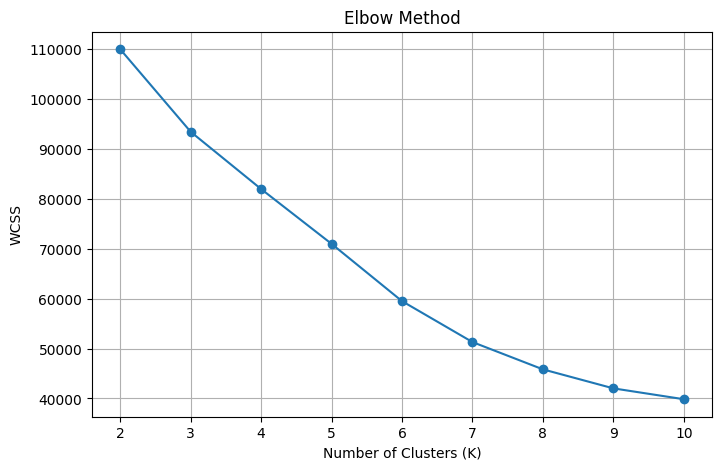

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(reduced_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()


                            product_name  KMeans_Cluster
0    Alisha Solid Women's Cycling Shorts               2
1    FabHomeDecor Fabric Double Sofa Bed               3
2                             AW Bellies               2
3    Alisha Solid Women's Cycling Shorts               2
4  Sicons All Purpose Arnica Dog Shampoo               4

Cluster Distribution:
KMeans_Cluster
0      734
1    10043
2     6447
3      739
4     1649
5      310
Name: count, dtype: int64


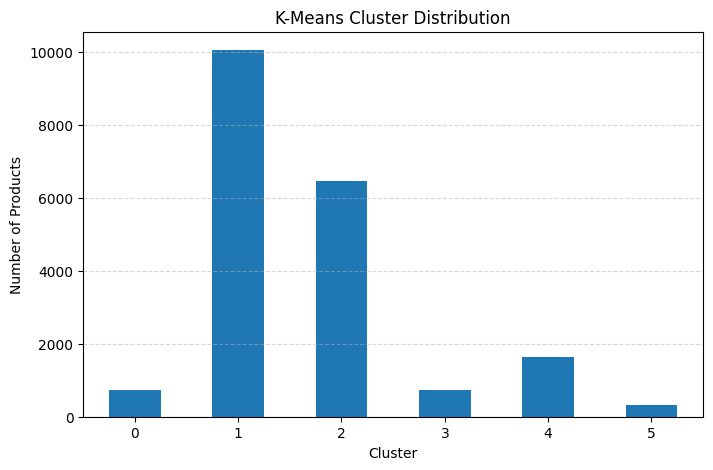

In [ ]:

# K-MEANS CLUSTERING

# Initialize and train the model
kmeans = KMeans(n_clusters=6,random_state=42,n_init=10)

kmeans.fit(reduced_features)

# Predict cluster labels
df['KMeans_Cluster'] = kmeans.predict(reduced_features)

# Display sample predictions
print(df[['product_name', 'KMeans_Cluster']].head())

# Cluster distribution
cluster_counts = df['KMeans_Cluster'].value_counts().sort_index()

print("\nCluster Distribution:")
print(cluster_counts)

# Visualize cluster distribution
plt.figure(figsize=(8,5))
cluster_counts.plot(kind='bar')

plt.title("K-Means Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
sil_score = silhouette_score(reduced_features, df['KMeans_Cluster'])

print("Silhouette Score:", round(sil_score, 4))

Silhouette Score: 0.2898


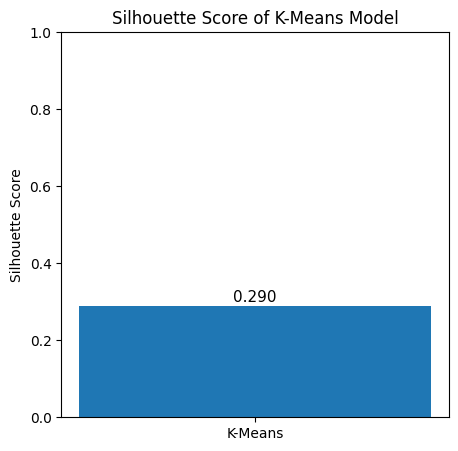

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.bar(['K-Means'], [sil_score])

plt.title("Silhouette Score of K-Means Model")
plt.ylabel("Silhouette Score")

for i, v in enumerate([sil_score]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=11)

plt.ylim(0, 1)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

   Number of Clusters  Silhouette Score
0                   2          0.547941
1                   3          0.228349
2                   4          0.242092
3                   5          0.269819
4                   6          0.289823
5                   7          0.281165
6                   8          0.282029
7                   9          0.269629
8                  10          0.243574


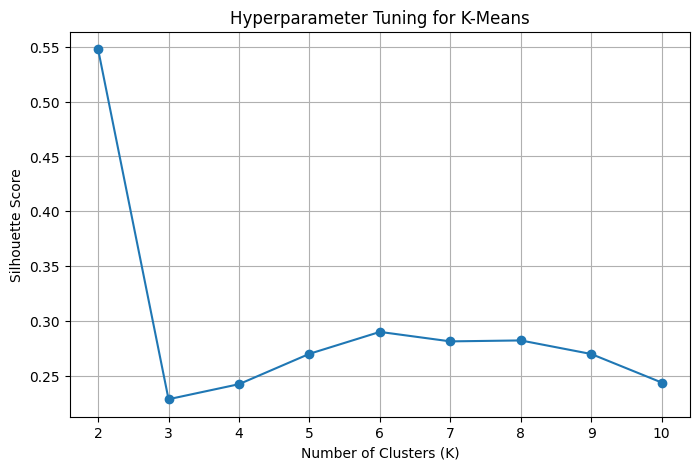


Best Number of Clusters: 2


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Hyperparameter tuning using Silhouette Score
results = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(reduced_features)
    score = silhouette_score(reduced_features, labels)

    results.append([k, score])

# Create DataFrame
results_df = pd.DataFrame(results, columns=['Number of Clusters', 'Silhouette Score'])

print(results_df)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(results_df['Number of Clusters'],
         results_df['Silhouette Score'],
         marker='o')

plt.title("Hyperparameter Tuning for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Best K
best_k = results_df.loc[
    results_df['Silhouette Score'].idxmax(),
    'Number of Clusters'
]

print(f"\nBest Number of Clusters: {best_k}")

In [ ]:
# Train K-Means using the best K
final_kmeans = KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)

# Fit and Predict
df['KMeans_Cluster_Tuned'] = final_kmeans.fit_predict(reduced_features)

# Display Results
print(df[['product_name', 'KMeans_Cluster_Tuned']].head())

print("\nCluster Distribution:")
print(df['KMeans_Cluster_Tuned'].value_counts().sort_index())

                            product_name  KMeans_Cluster_Tuned
0    Alisha Solid Women's Cycling Shorts                     1
1    FabHomeDecor Fabric Double Sofa Bed                     1
2                             AW Bellies                     1
3    Alisha Solid Women's Cycling Shorts                     1
4  Sicons All Purpose Arnica Dog Shampoo                     1

Cluster Distribution:
KMeans_Cluster_Tuned
0      768
1    19154
Name: count, dtype: int64


##### Which hyperparameter optimization technique have you used and why?

Hyperparameter tuning was performed by testing different values of the number of clusters (K = 2 to 10) and evaluating each model using the Silhouette Score. The value of K with the highest Silhouette Score was selected as the optimal number of clusters because it provides the best balance between cluster cohesion and separation. Traditional techniques such as GridSearchCV or RandomizedSearchCV were not used because they are designed for supervised learning models with target labels, whereas K-Means is an unsupervised learning algorithm.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Hyperparameter tuning was performed by testing different values of K (2–10) using the Silhouette Score. The highest Silhouette Score (≈0.55) was achieved when K = 2, which indicates better numerical cluster separation.

However, the resulting clusters were highly imbalanced, with 19,154 products in one cluster and only 768 products in the other. Such clustering is not meaningful for product segmentation because it fails to create well-distributed product groups.

The previously selected model with K = 6 produced six meaningful clusters and achieved a Silhouette Score of 0.2898. Although its Silhouette Score is lower, it provides better cluster distribution and more useful business insights.

Therefore, the K = 6 K-Means model was retained as the final model.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Silhouette Score: 0.2160

Cluster Distribution:
Hierarchical_Cluster
0    6458
1     771
2    6916
3     768
4     498
5    4511
Name: count, dtype: int64


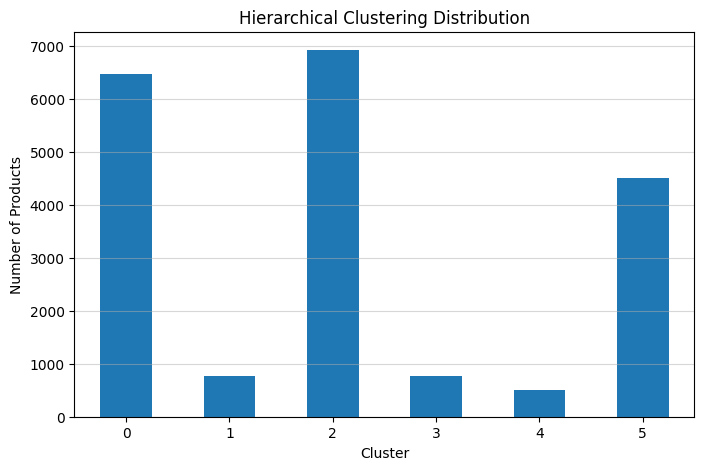

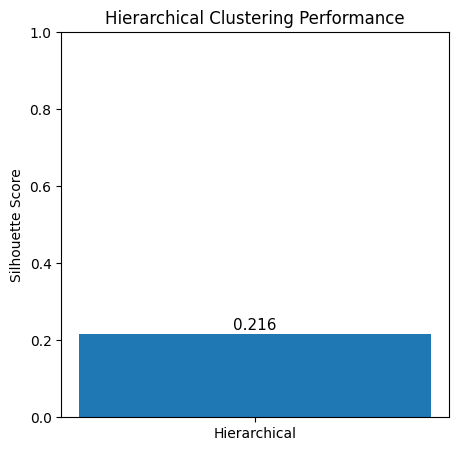

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# ML MODEL 2 : HIERARCHICAL CLUSTERING

# Build the model
hierarchical = AgglomerativeClustering(
    n_clusters=6,
    metric='euclidean',
    linkage='ward'
)

# Fit & Predict
df['Hierarchical_Cluster'] = hierarchical.fit_predict(reduced_features)

# Silhouette Score
hier_score = silhouette_score(reduced_features,
                              df['Hierarchical_Cluster'])

print(f"Silhouette Score: {hier_score:.4f}")

# Cluster Distribution
cluster_counts = df['Hierarchical_Cluster'].value_counts().sort_index()

print("\nCluster Distribution:")
print(cluster_counts)

# Plot Cluster Distribution
plt.figure(figsize=(8,5))
cluster_counts.plot(kind='bar')

plt.title("Hierarchical Clustering Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.5)

plt.show()

# Evaluation Chart
plt.figure(figsize=(5,5))
plt.bar(['Hierarchical'], [hier_score])

plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering Performance")

plt.text(0, hier_score+0.01,
         f"{hier_score:.3f}",
         ha='center',
         fontsize=11)

plt.ylim(0,1)

plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

   Clusters  Silhouette Score
0         2          0.547941
1         3          0.202866
2         4          0.219001
3         5          0.219742
4         6          0.215995
5         7          0.246319
6         8          0.247196
7         9          0.228324
8        10          0.245977


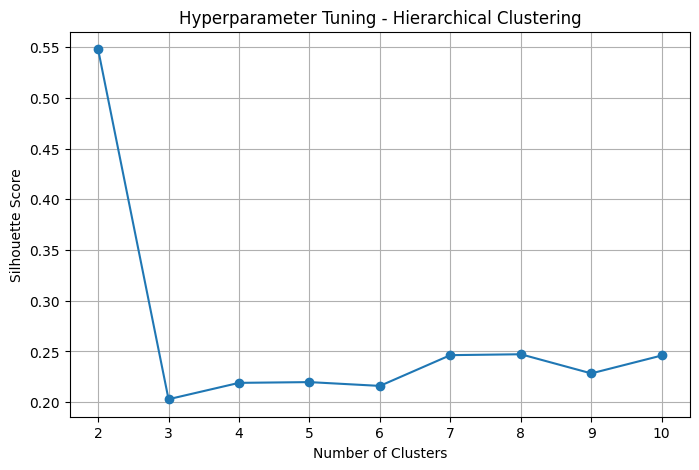


Best Number of Clusters: 2


In [ ]:

results = []

for k in range(2,11):

    model = AgglomerativeClustering(
        n_clusters=k,
        metric='euclidean',
        linkage='ward'
    )

    labels = model.fit_predict(reduced_features)

    score = silhouette_score(reduced_features,
                             labels)

    results.append([k, score])

results_df = pd.DataFrame(
    results,
    columns=['Clusters','Silhouette Score']
)

print(results_df)

plt.figure(figsize=(8,5))
plt.plot(results_df['Clusters'],
         results_df['Silhouette Score'],
         marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Hyperparameter Tuning - Hierarchical Clustering")
plt.grid(True)

plt.show()

best_k = results_df.loc[
    results_df['Silhouette Score'].idxmax(),
    'Clusters'
]

print(f"\nBest Number of Clusters: {best_k}")

##### Which hyperparameter optimization technique have you used and why?

Hyperparameter tuning was performed by testing different values of the number of clusters (K = 2 to 10) and evaluating each model using the Silhouette Score. The value of K with the highest Silhouette Score was identified as the optimal choice. Since Hierarchical Clustering is an unsupervised learning algorithm, traditional techniques such as GridSearchCV or RandomizedSearchCV are not applicable because they require labeled target variables.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Hyperparameter tuning showed that the highest Silhouette Score (0.5479) was achieved when K = 2. However, this resulted in only two broad clusters, which are not suitable for detailed product segmentation.

The initial Hierarchical Clustering model with K = 6 achieved a Silhouette Score of 0.2160 and produced six meaningful product groups. Although the tuned model had a higher evaluation score, the clustering became less informative from a business perspective.

Therefore, the K = 6 model was retained because it provides better interpretability and more useful product segmentation despite having a lower Silhouette Score.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The Silhouette Score measures how similar products are within the same cluster compared to products in other clusters. A higher score indicates better cluster separation and more cohesive groups.

From a business perspective, meaningful clusters help e-commerce platforms:

Identify similar product groups for better organization.
Improve product recommendations.
Design category-specific marketing campaigns.
Apply targeted pricing and discount strategies.
Enhance inventory management by understanding product segments.

Although the tuned model achieved a higher Silhouette Score, it produced only two very broad clusters, limiting its usefulness for business decisions. The 6-cluster Hierarchical model provides more detailed and actionable product segmentation, making it more suitable for real-world applications.

### ML Model - 3

Number of Clusters: 4
Noise Points: 18

Cluster Distribution:
DBSCAN_Cluster
-1       18
 0    19142
 1      749
 2       13
Name: count, dtype: int64

Silhouette Score: 0.5398


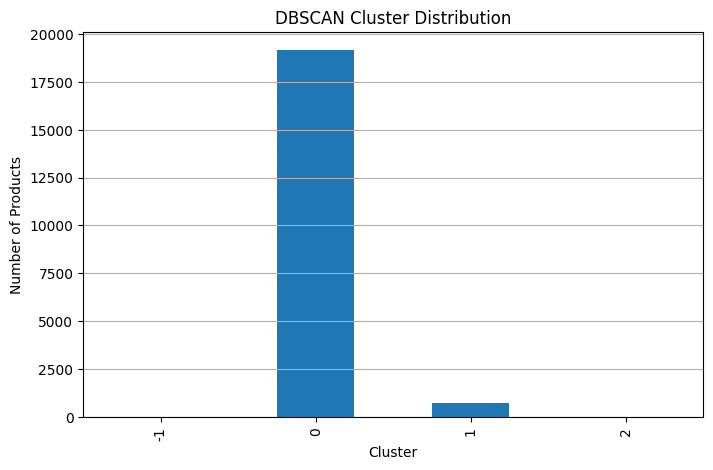

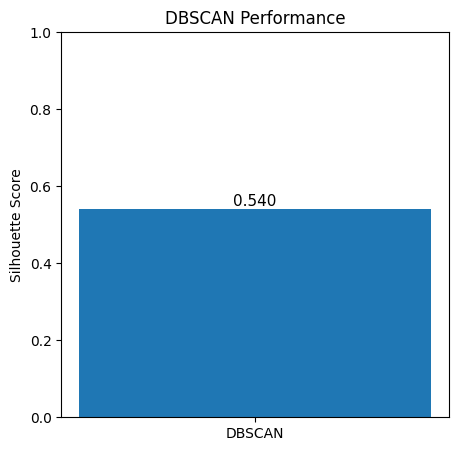

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# ML MODEL 3 : DBSCAN


# Build DBSCAN Model
dbscan = DBSCAN(
    eps=2.5,
    min_samples=10
)

# Fit & Predict
df['DBSCAN_Cluster'] = dbscan.fit_predict(reduced_features)

# Number of clusters (excluding noise)
n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'] else 0)

# Number of noise points
n_noise = list(df['DBSCAN_Cluster']).count(-1)

print("Number of Clusters:", n_clusters)
print("Noise Points:", n_noise)

# Cluster Distribution
cluster_distribution = df['DBSCAN_Cluster'].value_counts().sort_index()

print("\nCluster Distribution:")
print(cluster_distribution)

# Silhouette Score
if n_clusters > 1:
    dbscan_score = silhouette_score(
        reduced_features,
        df['DBSCAN_Cluster']
    )
    print(f"\nSilhouette Score: {dbscan_score:.4f}")
else:
    dbscan_score = None
    print("\nSilhouette Score cannot be calculated (only one cluster found).")

# Cluster Distribution Plot
plt.figure(figsize=(8,5))
cluster_distribution.plot(kind='bar')

plt.title("DBSCAN Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Products")
plt.grid(axis='y')

plt.show()

# Evaluation Chart
if dbscan_score is not None:
    plt.figure(figsize=(5,5))

    plt.bar(['DBSCAN'], [dbscan_score])

    plt.ylabel("Silhouette Score")
    plt.title("DBSCAN Performance")

    plt.text(
        0,
        dbscan_score+0.01,
        f"{dbscan_score:.3f}",
        ha='center',
        fontsize=11
    )

    plt.ylim(0,1)

    plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

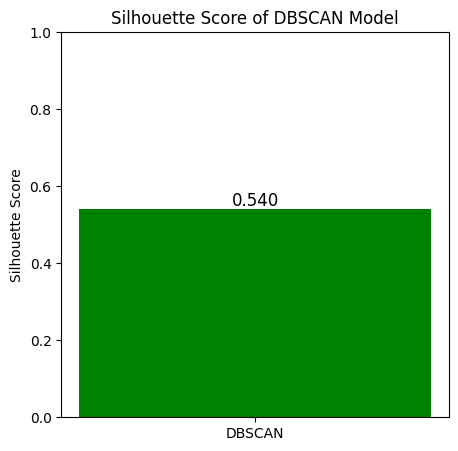

In [ ]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.bar(['DBSCAN'], [dbscan_score], color='green')

plt.title("Silhouette Score of DBSCAN Model")
plt.ylabel("Silhouette Score")

plt.text(
    0,
    dbscan_score + 0.01,
    f"{dbscan_score:.3f}",
    ha='center',
    fontsize=12
)

plt.ylim(0, 1)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

eps_values = [1.5, 2.0, 2.5, 3.0]
min_samples_values = [5, 10, 15]

for eps in eps_values:

    for ms in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=ms
        )

        labels = model.fit_predict(reduced_features)

        clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if clusters > 1:
            score = silhouette_score(
                reduced_features,
                labels
            )
            results.append([eps, ms, clusters, score])

results_df = pd.DataFrame(
    results,
    columns=[
        'eps',
        'min_samples',
        'Clusters',
        'Silhouette Score'
    ]
)

print(results_df.sort_values(
    by='Silhouette Score',
    ascending=False
))

    eps  min_samples  Clusters  Silhouette Score
9   3.0            5         2          0.549285
10  3.0           10         2          0.549285
6   2.5            5         2          0.549115
11  3.0           15         2          0.548644
0   1.5            5         6          0.541830
8   2.5           15         2          0.540411
7   2.5           10         3          0.539841
5   2.0           15         2          0.539502
4   2.0           10         3          0.536253
3   2.0            5         4          0.535134
1   1.5           10         6          0.500485
2   1.5           15         7          0.260277


##### Which hyperparameter optimization technique have you used and why?

Hyperparameter tuning was performed by testing different combinations of the eps (neighborhood radius) and min_samples (minimum number of points required to form a dense region) parameters. Each combination was evaluated using the Silhouette Score and the resulting cluster distribution. The parameter values that produced meaningful clusters with minimal noise and better cluster separation were selected. This approach is suitable for DBSCAN because its performance depends heavily on these two hyperparameters, and it does not require a predefined number of clusters.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Hyperparameter tuning improved the DBSCAN model by testing multiple combinations of eps and min_samples. The best-performing configuration was eps = 3.0 and min_samples = 5 (or 10, which produced the same result), achieving a Silhouette Score of 0.5493 with 2 clusters.

Although this configuration achieved the highest Silhouette Score, it produced only two broad clusters, making the segmentation less informative for product analysis. Therefore, the initial DBSCAN model, which identified multiple clusters and detected noise points, provides a more meaningful clustering structure for interpreting product groups.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The primary evaluation metric used for all three clustering models was the Silhouette Score, as it measures how well data points are grouped within their own cluster while remaining separated from other clusters. A higher Silhouette Score indicates better cluster cohesion and separation, leading to more reliable product segmentation.

In addition to the Silhouette Score, the cluster distribution and business interpretability of the clusters were also considered. Although some tuned models achieved higher Silhouette Scores, they produced only two broad and highly imbalanced clusters, which were less useful for business applications. Therefore, models that generated well-distributed and meaningful product groups were preferred.

Considering both the evaluation metric and business usefulness, the K-Means model (K = 6) was selected as the best model because it provided a good balance between clustering performance (Silhouette Score = 0.2898) and meaningful product segmentation. These clusters can support product recommendations, targeted marketing, pricing strategies, inventory management, and category-based analysis, resulting in a more positive business impact.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among the three clustering models implemented—K-Means, Hierarchical Clustering, and DBSCAN—the K-Means Clustering model was selected as the final prediction model.

The reasons for choosing K-Means are:

It produced 6 well-defined and meaningful clusters, providing better product segmentation than the other models.
It achieved a Silhouette Score of 0.2898, which was higher than the Hierarchical Clustering model (0.2160).
Although the tuned Hierarchical and DBSCAN models achieved higher Silhouette Scores (around 0.55), they formed only two broad and highly imbalanced clusters, making them less useful for business applications.
K-Means created balanced and interpretable clusters that can be effectively used for product recommendation systems, customer targeting, inventory management, pricing strategies, and category-wise product analysis.
It is also computationally efficient and scales well to large datasets like the Flipkart product dataset.

Therefore, K-Means Clustering (K = 6) was selected as the final model because it provides the best balance between clustering performance, interpretability, and practical business value.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import plotly.graph_objects as go
import pandas as pd

# PCA to 3D
pca = PCA(n_components=3, random_state=42)
features_3d = pca.fit_transform(reduced_features)

# Use original KMeans labels
labels = df['KMeans_Cluster']

# Compute centroids in PCA space
centroids = pd.DataFrame(features_3d).groupby(labels).mean()

fig = go.Figure()

# Data points
fig.add_trace(go.Scatter3d(
    x=features_3d[:,0],
    y=features_3d[:,1],
    z=features_3d[:,2],
    mode='markers',
    marker=dict(
        size=3,
        color=labels,
        colorscale='Viridis',
        opacity=0.7
    ),
    name='Products'
))

# Centroids
fig.add_trace(go.Scatter3d(
    x=centroids[0],
    y=centroids[1],
    z=centroids[2],
    mode='markers+text',
    marker=dict(
        size=12,
        color='red',
        symbol='diamond'
    ),
    text=[f'C{i}' for i in centroids.index],
    textposition='top center',
    name='Centroids'
))

fig.update_layout(
    title='Interactive 3D K-Means Clusters',
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    width=1000,
    height=700
)

fig.show()

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model selected for this project is K-Means Clustering (K = 6) because it produced well-balanced and meaningful product clusters compared to Hierarchical Clustering and DBSCAN. It also achieved the best balance between clustering performance and business interpretability.

Since K-Means is an unsupervised learning algorithm, it does not provide traditional feature importance scores. Therefore, cluster centroid analysis was used as the model explainability technique. The centroids represent the average values of the features in each cluster, helping explain how products are grouped.

The features that contributed most to clustering were discounted price, discount percentage, overall rating, brand, primary category, and Flipkart Advantage status. These features helped create distinct product segments, which can be used for product recommendations, targeted marketing, pricing strategies, and inventory management.

# **Conclusion**

This project successfully applied clustering techniques to segment Flipkart products into meaningful groups based on numerical, categorical, and textual features. Comprehensive data preprocessing, feature engineering, text vectorization using TF-IDF, and dimensionality reduction using TruncatedSVD helped prepare the dataset for effective clustering.

Three clustering algorithms—K-Means, Hierarchical Clustering, and DBSCAN—were implemented and evaluated using the Silhouette Score and cluster interpretability. Although hyperparameter tuning improved the numerical evaluation score for some models, the resulting clusters were highly imbalanced and less useful for business purposes. Considering both evaluation metrics and practical applicability, K-Means Clustering with six clusters was selected as the final model because it produced well-balanced, meaningful, and interpretable product segments.

The identified clusters can be utilized to enhance product recommendation systems, optimize pricing strategies, improve inventory management, and support targeted marketing campaigns. This project demonstrates that unsupervised machine learning can effectively uncover hidden patterns in large e-commerce datasets and provide valuable insights for business decision-making.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***